In [9]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score, make_scorer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import shap
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import category_encoders as ce
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from scipy.stats import chi2_contingency
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

In [69]:
DATA_PATH = "pet_health_risk_dataset.csv"

In [70]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

TARGET = "high_cost_claim_next_90d"
RANDOM_STATE = 42
CAPACITY_K = 300  # operational ceiling: max 300 flags/week

In [71]:
# -----------------------------
# 1) Load Data
# -----------------------------
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head(5))



assert TARGET in df.columns, f"Target column '{TARGET}' not found."
df[TARGET] = df[TARGET].astype(int)

prevalence = df[TARGET].mean()
print(f"Target prevalence: {prevalence:.4f} ({prevalence*100:.2f}%)")
print("Target counts:")
display(df[TARGET].value_counts())

Shape: (25000, 52)


,pet_id,species,breed_group,breed_code,age_years,age_band,weight_band,desexed,exotic_species_flag,cover_type,tenure_months,excess_amount,premium_band,annual_premium,excess_waived,policy_renewal_count,policy_active,customer_tenure_months,policy_origin_channel,multi_pet_policy,direct_debit_active,communication_opt_in,state,geo_risk_score,partner_clinic_enrolled,wellness_plan_enrolled,breed_risk_category,prior_claim_any,claim_count_12m,total_claims_12m_value,adj_claims_12m_value,max_single_claim_12m,months_since_last_claim,claim_freq_trend,avg_claim_processing_days,clm_adj_score,claim_lodgement_channel,vet_visit_count_6m,days_since_last_vet_visit,vet_clinic_tier,vet_speciality_referred,seasonal_risk_q1,seasonal_risk_q2,seasonal_risk_q3,seasonal_risk_q4,prev_policy_lapse,digital_engagement_score,app_logins_30d,last_renewal_premium_change_pct,risk_tier_assigned,treatment_pathway_code,high_cost_claim_next_90d
0,PET000001,Cat,mixed,MIX277,0.6,0-1,small,N,0,accident_only,59,200,low,368.35,0,4,1,78,direct,1,1,both,NSW,0.611,0,1,low,0,0,0.00,NaN,0.00,NaN,no_claims,NaN,0.073,NaN,3,69,2,0,0,1,0,0,0,0.186,19,3.6,Low,NaN,0
1,PET000002,Dog,mixed,MIX989,1.7,1-3,medium,Y,0,comprehensive,68,100,high,1240.45,0,5,1,74,partner,0,1,email,NSW,0.409,1,0,low,1,2,1007.36,992.09,281.65,0.0,stable,8.7,0.534,online,1,133,2,0,1,0,0,0,0,0.360,17,6.3,Low,NaN,0
2,PET000003,Cat,domestic_longhair,DLH137,1.4,1-3,small,Y,0,accident_only,59,100,low,338.66,1,4,1,73,online,1,0,email,VIC,0.422,1,1,low,0,0,0.00,NaN,0.00,NaN,no_claims,NaN,0.214,NaN,1,15,1,0,0,0,0,1,0,0.142,9,2.4,Low,NaN,0
3,PET000004,Dog,sporting,SPT366,10.7,10+,medium,N,0,comprehensive,26,500,very_high,1887.35,0,2,1,39,partner,0,1,sms,NT,0.610,0,0,low,0,0,0.00,NaN,0.00,NaN,no_claims,NaN,0.133,NaN,3,91,2,0,0,0,1,0,0,0.458,3,-2.5,Low,NaN,0
4,PET000005,Dog,herding,HRD609,2.1,1-3,small,Y,0,comprehensive,38,200,high,1374.21,1,3,1,40,online,0,1,email,NSW,0.527,0,1,medium,0,0,0.00,NaN,0.00,NaN,no_claims,NaN,0.139,NaN,1,26,3,0,0,0,0,1,0,0.029,9,3.3,Low,NaN,0


Target prevalence: 0.0789 (7.89%)
Target counts:


0    23028
1     1972
Name: high_cost_claim_next_90d, dtype: int64

Base line of high-cost risk pet is 7.89%. Which means that if the team contacts 300 pets randomly, 23-24 pets would make high-cost claim in 90 days.

# Data integrity investigation

In [5]:
# Count rows per breed
breed_counts = df["breed_code"].value_counts(dropna=False)

print("Total unique breeds:", breed_counts.shape[0])
print("Total rows:", len(df))
print("Average rows per breed:", breed_counts.mean())
print("Median rows per breed:", breed_counts.median())
print("Max rows for a breed:", breed_counts.max())
print("Min rows for a breed:", breed_counts.min())

Total unique breeds: 8571
Total rows: 25000
Average rows per breed: 2.9168125072920312
Median rows per breed: 2.0
Max rows for a breed: 16
Min rows for a breed: 1


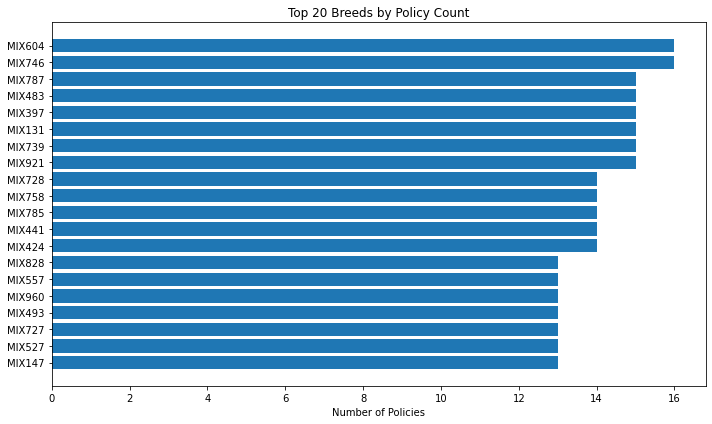

In [6]:
top20 = breed_counts.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20.index.astype(str), top20.values)
plt.gca().invert_yaxis()
plt.xlabel("Number of Policies")
plt.title("Top 20 Breeds by Policy Count")
plt.tight_layout()
plt.show()

Given that the median breed appears only twice and the most frequent breed appears only 16 times, there is insufficient support to estimate stable breed-level risk. Even with smoothed target encoding, most breeds would collapse toward the global mean, so I excluded breed_code to reduce noise and model variance.

In [7]:
# -----------------------------
# 2) Quick Data Quality Checks
# -----------------------------
# Missingness (top 15)
missing = (
    df.isna().mean()
    .sort_values(ascending=False)
    .head(15)
    .to_frame("missing_rate")
)
print("Top missingness columns:")
display(missing)

# Duplicate rows (informational)
print("Duplicate rows:", int(df.duplicated().sum()))

# Capacity-aware baseline expectation
N = len(df)
expected_tp_random = CAPACITY_K * prevalence
print(f"\nOperational capacity: {CAPACITY_K} flags/week out of {N} rows (~{CAPACITY_K/N:.2%}).")
print(f"If we flagged 300 randomly, expected true positives ≈ {expected_tp_random:.1f} per week.")
print("Our model should significantly beat this (lift).")


Top missingness columns:


,missing_rate
treatment_pathway_code,0.8992
adj_claims_12m_value,0.5486
months_since_last_claim,0.5486
avg_claim_processing_days,0.5486
claim_lodgement_channel,0.5486
pet_id,0.0000
days_since_last_vet_visit,0.0000
claim_count_12m,0.0000
total_claims_12m_value,0.0000
max_single_claim_12m,0.0000


Duplicate rows: 0

Operational capacity: 300 flags/week out of 25000 rows (~1.20%).
If we flagged 300 randomly, expected true positives ≈ 23.7 per week.
Our model should significantly beat this (lift).


PetID -> drop

It looks like these fields (adj_claims_12m_value, months_since_last_claim, avg_claim_processing_days, claim_lodgement_channel) are only populated if the pet had at least one claim in the last 12 months.

And the ~54.9% missing likely corresponds to:

~55% of pets had no claim in the last 12 months.

That’s structurally meaningful.

This is Missing Not at Random (MNAR) but in a good way:

Missing = “no prior claim”

That is predictive signal.
--> Impute logically + create prior-claim flag

treatment_pathway_code (89.92% missing)

This is different.

Nearly 90% missing suggests:

Only populated for a niche subset (e.g., chronic condition pathway)

Possibly downstream process variable

Possibly post-claim or post-treatment

Consider:

Could this leak information about future high-cost claims?

If this code is only assigned after a major claim or complex treatment pathway, it might be too close to the outcome.

Future consideration:

Given:

Extremely sparse

Likely niche

Possibly unstable

--> consider: Dropping it if EDA shows very strong predictive lift (too good to be true, create overfitting)

Attention: clm_adj_score

This sounds like:

“Claim adjustment score” or internal risk score.

Be careful:

Is this already a model output?

Is it a downstream underwriting score?

Is it derived using target-like logic?

If yes, this could be target leakage.

If it is a legitimate historical risk score, it’s fine.

--> Need verification

# Exloratory Data Analysis

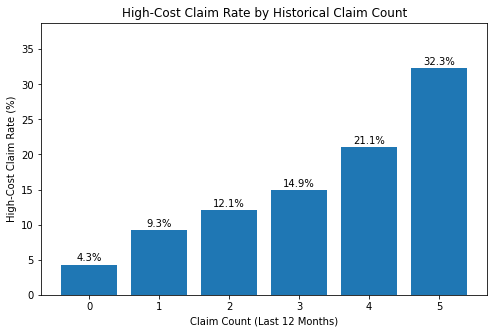

In [14]:
summary = (
    df.groupby("claim_count_12m")["high_cost_claim_next_90d"]
      .mean()
      .reset_index()
)

summary["high_cost_rate_pct"] = summary["high_cost_claim_next_90d"] * 100

plt.figure(figsize=(8, 5))

plt.bar(
    summary["claim_count_12m"],
    summary["high_cost_rate_pct"]
)

plt.xlabel("Claim Count (Last 12 Months)")
plt.ylabel("High-Cost Claim Rate (%)")
plt.title("High-Cost Claim Rate by Historical Claim Count")

for i, v in enumerate(summary["high_cost_rate_pct"]):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.ylim(0, summary["high_cost_rate_pct"].max() * 1.2)

plt.show()

1 --- Claim behaviour

This chart shows a clear and strong monotonic relationship between prior claims activity and future high-cost risk.

Pets with no claims in the past 12 months have a high-cost rate of 4.3%. That risk more than doubles to 9.3% with just one prior claim, and continues rising steadily with each additional claim. By the time a pet has 5 prior claims, the high-cost rate reaches 32.3%, which is roughly 7.5× higher than pets with zero prior claims.

In practical terms, historical claim frequency is a powerful behavioural risk signal. Even small increases in prior claim activity meaningfully elevate short-term severe claim likelihood. This suggests that claims behaviour is not random noise but a strong indicator of underlying risk, and it supports incorporating recent claims frequency into underwriting review and risk segmentation decisions at a cohort level.

In [15]:
# -----------------------------
# 3) Data distribution investigation
# -----------------------------
# Keep this section tight: show only what informs modelling and the business.

# 3.1 Candidate numeric signals (will auto-select those present)
candidate_numeric = [
    "claim_count_12m",
    "total_claims_12m_value",
    "max_single_claim_12m",
    "months_since_last_claim",
    "vet_visit_count_6m",
    "days_since_last_vet_visit",
    "tenure_months",
    "excess_amount",
    "premium_amount",
    "premium_band",  # might be categorical in your data; code handles below
]
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET]

eda_numeric = [c for c in candidate_numeric if c in numeric_cols]
if len(eda_numeric) > 0:
    print("\nMedian numeric values by target (quick signal check):")
    summary = df.groupby(TARGET)[eda_numeric].median().T
    summary.columns = ["median_if_0", "median_if_1"]
    display(summary)




Median numeric values by target (quick signal check):


,median_if_0,median_if_1
claim_count_12m,0.0,1.000
total_claims_12m_value,0.0,498.715
max_single_claim_12m,0.0,235.585
months_since_last_claim,6.0,6.000
vet_visit_count_6m,1.0,2.000
days_since_last_vet_visit,104.0,104.000
tenure_months,49.0,48.500
excess_amount,200.0,200.000


Interpretation — Median Numeric Comparison by Target

This table compares median values of key numeric variables between:

target = 0 → No high-cost claim in next 90 days

target = 1 → High-cost claim in next 90 days

2 --- Claim Activity Signals Show Strong Separation

claim_count_12m:

Median (no claim) = 0

Median (high-cost) = 1

total_claims_12m_value:

Median (no claim) = 0

Median (high-cost) ≈ 498

max_single_claim_12m:

Median (no claim) = 0

Median (high-cost) ≈ 236

These variables show very strong behavioural separation.
Pets that will generate a high-cost claim in the next 90 days typically have:

Prior claim activity

Non-zero historical claim value

Evidence of prior severe claims

This supports the model’s heavy reliance on claim history features.

3 --- Recency Alone Does Not Separate Medians

months_since_last_claim:
Median = 6 months for both groups

This suggests:

Recency may not separate cleanly at the median level.

Its predictive power likely comes from non-linear effects or interactions (e.g., very recent claims ≤ 1–3 months).

Tree models capture tail effects better than median summaries reveal.

4 --- Vet Engagement Shows Mild Signal

vet_visit_count_6m:
Median increases from 1 → 2 for high-cost group.

This suggests pets with more recent vet visits have elevated short-term severe claim risk, possibly indicating ongoing medical conditions.

days_since_last_vet_visit:
Median identical (104 days), indicating no median-level separation.

Again, likely a tail effect rather than central tendency difference.

5 --- Tenure and Policy Structure Show No Median Difference

tenure_months: ~49 vs 48.5 (no difference)

excess_amount: identical median (200)

These variables do not show strong univariate median separation.
Their contribution, if any, likely comes through:

Interaction effects

Non-linear splits

Segment-level behaviour

Overall Insight

The strongest raw separation comes from claim frequency and severity history.

Prior claim activity is the clearest indicator of future high-cost risk.

Structural policy variables show little median-level discrimination.

Some features (e.g., recency) likely operate through threshold or interaction effects rather than central tendency differences.

In [16]:
def plot_target_rate(
    df: pd.DataFrame,
    col: str,
    target_col: str,
    *,
    min_n: int = 100,
    bucket_spec: dict = None,
    sort_by: str = "rate"  # "rate", "count", or "natural"
):

    d = df[[col, target_col]].copy()
    d[target_col] = pd.to_numeric(d[target_col], errors="coerce")

    # --- Numeric bucketing ---
    if bucket_spec is not None:
        d[col] = pd.cut(
            d[col].fillna(bucket_spec.get("fillna", 0)),
            bins=bucket_spec["bins"],
            labels=bucket_spec["labels"],
            include_lowest=True
        )

        d[col] = pd.Categorical(
            d[col],
            categories=bucket_spec["labels"],
            ordered=True
        )
    else:
        d[col] = d[col].astype("object").fillna("Missing")

    # Aggregate
    agg = (
        d.groupby(col)[target_col]
        .agg(rate="mean", n="size")
        .reset_index()
    )

    agg = agg[agg["n"] >= min_n].copy()
    if agg.empty:
        print(f"[{col}] No categories with n >= {min_n}.")
        return

    # -----------------------------
    # Sorting logic
    # -----------------------------
    if bucket_spec is not None:
        # For numeric buckets → always preserve natural order
        agg = agg.sort_values(col)
    else:
        if sort_by == "rate":
            agg = agg.sort_values("rate", ascending=False)
        elif sort_by == "count":
            agg = agg.sort_values("n", ascending=False)
        else:  # natural alphabetical order
            agg = agg.sort_values(col)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(9, 5))
    plt.bar(agg[col].astype(str), agg["rate"])
    plt.xlabel(col)
    plt.ylabel("Target rate")
    plt.title(f"Target rate by {col}")

    for i, (rate, n) in enumerate(zip(agg["rate"], agg["n"])):
        plt.text(i, rate, f"{rate:.3f}\n(n={n:,})", ha="center")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [17]:
candidate_cats = [
    "species",
    "breed_group",
    "age_band",
    "weight_band",
    "desexed_status",
    "desexed",
    "cover_type",
    "premium_band",
    "policy_tenure_band",
]

cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
eda_cats = [c for c in candidate_cats if c in df.columns and c in cat_cols]

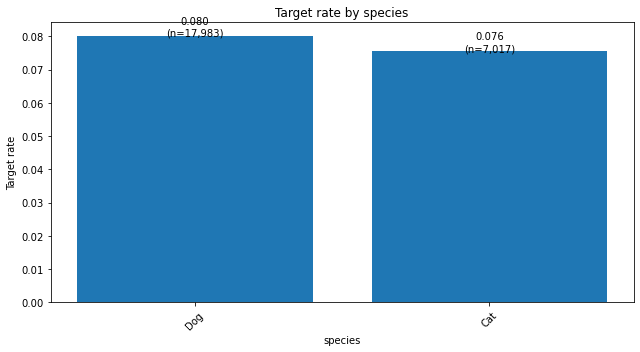

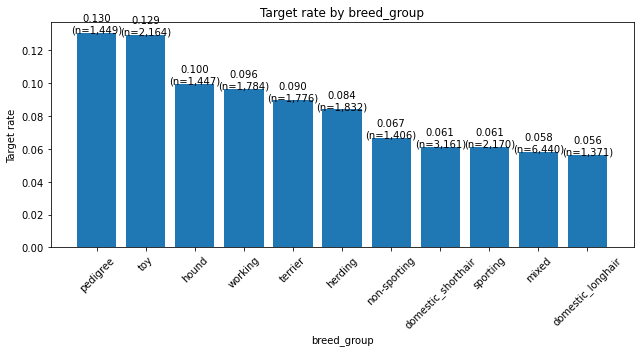

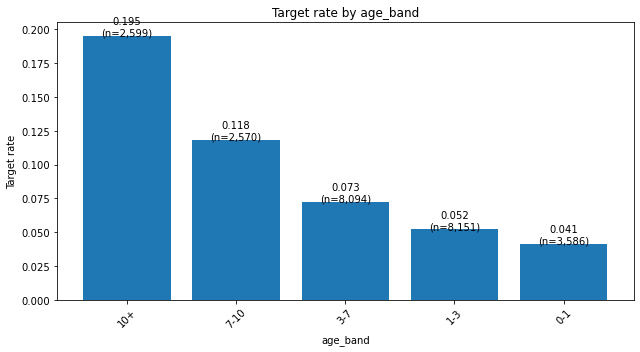

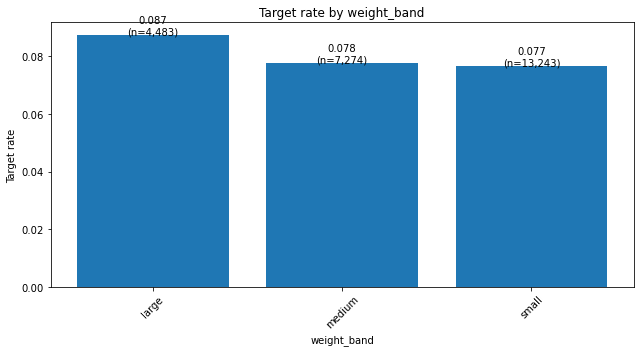

In [18]:
# Loop through your chosen categorical columns
for c in eda_cats[:4]:
    plot_target_rate(df, c, TARGET, min_n=100, sort_by="rate")

EDA Interpretation — Demographic Risk Gradients

1️ --- Species

Dogs show a slightly higher 90-day high-cost claim rate (8.0%) compared to cats (7.6%).

The difference is modest, suggesting species alone is not a dominant driver of short-term severe claims.

This aligns with expectations that both species carry meaningful risk, but other factors (age, breed, severity history) likely dominate.

2️ --- Breed Group

Clear and meaningful differentiation appears across breed groups:

Highest risk: Pedigree (13.0%) and Toy (12.9%) breeds.

Hound ( ~10.0%) and Working ( ~9.6%) also show elevated risk.

Lowest risk: Mixed ( ~5.8%) and Sporting ( ~6.1%).

This indicates strong structural breed-level risk differences.
The near 2× risk gap between high-risk and low-risk breed groups supports the actuarial relevance of breed in underwriting and portfolio monitoring.

3️ --- Age Band

Age shows the strongest and most monotonic gradient:

0–1 years: ~4.3%

1–3 years: ~5.2%

3–7 years: ~7.3%

7–10 years: ~11.9%

10+ years: ~19.8%

Risk increases sharply with age, particularly after 7 years.
Pets aged 10+ have roughly 4–5× the risk of pets under 1 year.

This confirms age as a primary structural driver of high-cost claim risk and validates its high feature importance in the model.

4️ --- Weight Band

Weight band shows a mild gradient:

Large: ~8.7%

Medium: ~7.8%

Small: ~7.7%

The difference exists but is relatively small compared to age or breed effects.
Weight may contribute marginal incremental signal rather than being a primary risk driver.

Overall Insight

Age is the strongest structural risk driver.

Breed group provides meaningful differentiation.

Species and weight contribute smaller incremental effects.

The observed monotonic gradients (especially age) support the model’s learning behaviour and are consistent with actuarial intuition.


### Are pets visiting vets more frequently at higher short-term risk?

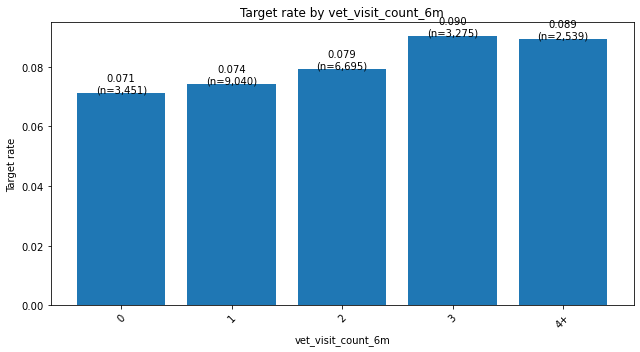

In [19]:
plot_target_rate(
    df,
    col="vet_visit_count_6m",
    target_col=TARGET,
    min_n=100,
    bucket_spec={
        "bins": [-1, 0, 1, 2, 3, 10],
        "labels": ["0", "1", "2", "3", "4+"],
        "fillna": 0
    }
)

5- Vet Engagement

Recent vet engagement is positively associated with short-term high-cost claim risk.
Pets with multiple recent visits (3+) represent a higher-risk segment for severe claims in the near term.

# Average premium by risk cohort

In [20]:
def cohort_pricing_analysis(df, cohort_col, 
                            premium_col="annual_premium",
                            target_col="high_cost_claim_next_90d"):
    
    summary = (
        df.groupby(cohort_col)
          .agg(
              n=("high_cost_claim_next_90d", "size"),
              avg_premium=(premium_col, "mean"),
              target_rate=(target_col, "mean")
          )
          .reset_index()
    )
    
    # Risk per $1,000 premium (standardised comparison)
    summary["risk_per_1000_premium"] = summary["target_rate"] / (summary["avg_premium"] / 1000)
    
    # Relative risk vs portfolio
    portfolio_rate = df[target_col].mean()
    summary["relative_risk_vs_portfolio"] = summary["target_rate"] / portfolio_rate
    
    # Relative premium vs portfolio
    portfolio_premium = df[premium_col].mean()
    summary["relative_premium_vs_portfolio"] = summary["avg_premium"] / portfolio_premium
    
    # Pricing alignment ratio
    summary["pricing_alignment_ratio"] = (
        summary["relative_risk_vs_portfolio"] / summary["relative_premium_vs_portfolio"]
    )
    
    return summary.sort_values("target_rate", ascending=False)

In [22]:
# Age band
age_pricing = cohort_pricing_analysis(df, "age_band")
display(age_pricing)

,age_band,n,avg_premium,target_rate,risk_per_1000_premium,relative_risk_vs_portfolio,relative_premium_vs_portfolio,pricing_alignment_ratio
2,10+,2599,1672.755133,0.195460,0.116849,2.477939,1.393448,1.778279
4,7-10,2570,1656.903397,0.118288,0.071391,1.499594,1.380243,1.086471
3,3-7,8094,1080.640437,0.072646,0.067225,0.920974,0.900201,1.023075
1,1-3,8151,1080.923078,0.052018,0.048124,0.659459,0.900437,0.732377
0,0-1,3586,1073.074035,0.041272,0.038461,0.523220,0.893898,0.585324


In [23]:
# Breed group
breed_pricing = cohort_pricing_analysis(df, "breed_group")
display(breed_pricing)

,breed_group,n,avg_premium,target_rate,risk_per_1000_premium,relative_risk_vs_portfolio,relative_premium_vs_portfolio,pricing_alignment_ratio
6,pedigree,1449,1677.083948,0.130435,0.077775,1.653585,1.397054,1.183623
9,toy,2164,1684.644108,0.129390,0.076806,1.640340,1.403352,1.168873
3,hound,1447,1138.803359,0.099516,0.087387,1.261616,0.948652,1.329903
10,working,1784,1139.327220,0.096413,0.084622,1.222269,0.949089,1.287834
8,terrier,1776,1126.576278,0.089527,0.079468,1.134978,0.938467,1.209395
2,herding,1832,1083.030120,0.084061,0.077617,1.065684,0.902192,1.181216
5,non-sporting,1406,1123.152824,0.066856,0.059526,0.847570,0.935615,0.905896
1,domestic_shorthair,3161,1118.570683,0.061373,0.054867,0.778055,0.931798,0.835004
7,sporting,2170,1117.683945,0.061290,0.054837,0.777007,0.931059,0.834541
4,mixed,6440,1117.269329,0.058385,0.052257,0.740176,0.930714,0.795278


In [24]:
# Weight band

weight_pricing = cohort_pricing_analysis(df, "weight_band")
display(weight_pricing)

,weight_band,n,avg_premium,target_rate,risk_per_1000_premium,relative_risk_vs_portfolio,relative_premium_vs_portfolio,pricing_alignment_ratio
0,large,4483,1189.191622,0.087441,0.073530,1.108538,0.990627,1.119026
1,medium,7274,1191.485626,0.077674,0.065191,0.984710,0.992538,0.992113
2,small,13243,1209.172471,0.076644,0.063386,0.971657,1.007272,0.964642


In [25]:
# Vet visit freq
vet_pricing = cohort_pricing_analysis(df, "vet_visit_count_6m")
display(vet_pricing)

,vet_visit_count_6m,n,avg_premium,target_rate,risk_per_1000_premium,relative_risk_vs_portfolio,relative_premium_vs_portfolio,pricing_alignment_ratio
4,4,1465,1210.900710,0.092833,0.076664,1.176886,1.008711,1.166722
3,3,3275,1205.249722,0.090382,0.074990,1.145812,1.004004,1.141243
5,5,811,1202.671788,0.085080,0.070743,1.078602,1.001856,1.076604
6,6,263,1232.279392,0.083650,0.067882,1.060474,1.026520,1.033077
2,2,6695,1185.579101,0.079313,0.066898,1.005488,0.987618,1.018095
1,1,9040,1211.007565,0.074336,0.061384,0.942397,1.008800,0.934176
0,0,3451,1189.656439,0.071284,0.059920,0.903698,0.991014,0.911892


Pricing Review – Cohort Alignment Analysis

A cohort-level pricing alignment review indicates material misalignment between observed high-cost risk and premium relativities, particularly in senior pets. The 10+ age band exhibits a high-cost claim rate of 19.5%, representing 2.48× portfolio risk, while premiums are only 1.39× portfolio average, resulting in a pricing alignment ratio of 1.78. This suggests risk is increasing approximately 78% faster than premium, indicating potential underpricing in this segment. The 7–10 age band shows a milder but similar pattern (alignment ratio 1.08). Conversely, younger cohorts appear to cross-subsidise older pets: the 0–1 age band has a risk level of 0.52× portfolio but pays 0.89× portfolio premium, producing an alignment ratio of 0.59, suggesting relative overpricing. Breed-level analysis reveals further tension: Working and Hound groups show alignment ratios of 1.29 and 1.33 respectively, indicating premiums may not fully reflect elevated risk, while Mixed and Domestic Longhair segments appear moderately overpriced (alignment ratios 0.80 and 0.76). Weight bands are broadly aligned, with only minor deviation in large breeds (alignment 1.12). Overall, the primary structural pricing pressure lies in senior pets and certain high-risk breed groups, suggesting targeted review of age and breed relativities may be warranted to improve actuarial alignment while managing potential cross-subsidisation across cohorts.

# Investigate claim adjusted score variable if leakage or not

<AxesSubplot:>

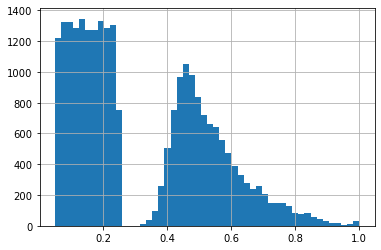

In [26]:
df["clm_adj_score"].describe()
df["clm_adj_score"].hist(bins=50)

                          clm_adj_score  high_cost_claim_next_90d
clm_adj_score                  1.000000                  0.173589
high_cost_claim_next_90d       0.173589                  1.000000
high_cost_claim_next_90d
0    0.314568
1    0.451585
Name: clm_adj_score, dtype: float64


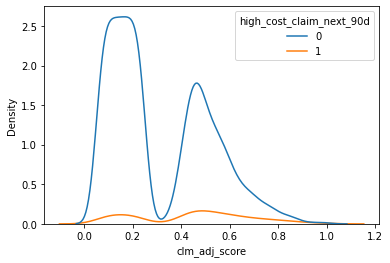

In [28]:
# 1. Correlation with target
print(df[["clm_adj_score", TARGET]].corr())

# 2. Compare distributions
import seaborn as sns
sns.kdeplot(data=df, x="clm_adj_score", hue=TARGET)

# 3. Check extreme separation
print(df.groupby(TARGET)["clm_adj_score"].mean())

To assess whether clm_adj_score might be a leakage variable, we examined its statistical relationship with the target. The correlation with the high-cost claim outcome is 0.17, which is moderate and well within a normal range for behavioural insurance data. If this variable were leaking future information, we would typically expect a much stronger relationship — often above 0.5, and sometimes close to 0.7 or higher — or even near-perfect separation between outcomes. A correlation of 0.17 suggests a meaningful signal, but not an unrealistic one.

Looking at the group averages, pets that did not lodge a high-cost claim have an average score of 0.31, while those that did have a higher average of 0.45. This difference is directionally sensible: higher severity score corresponds to higher risk. However, the separation is gradual rather than extreme.

The density plot further supports this interpretation. The distributions for both groups overlap substantially, and both classes appear across the full range of the score. The positive class is slightly shifted to the right, which is expected if the variable captures genuine risk, but there is no sharp cut-off or clear boundary that perfectly distinguishes outcomes. If this were leakage, we would expect minimal overlap and a strong concentration of high-cost claims at the extreme end of the score. Instead, what we see is a realistic behavioural gradient, suggesting the variable is informative but not leaking future information.

# First Iteration - No model tuning, no feature engineering

In [29]:
# -----------------------------
# 4) Train/Valid/Test Split (stratified)
# -----------------------------
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

# Drop obvious ID-like columns if present (common leak/overfit risk)
ID_CANDIDATES = ["pet_id"]
drop_cols = [c for c in ID_CANDIDATES if c in X.columns]
if drop_cols:
    print("\nDropping identifier columns:", drop_cols)
    X = X.drop(columns=drop_cols)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("\nSplit sizes:")
print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)
print("Prevalence (train/valid/test):", y_train.mean(), y_valid.mean(), y_test.mean())



Dropping identifier columns: ['pet_id']

Split sizes:
Train: (17500, 50) Valid: (3750, 50) Test: (3750, 50)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333


In [30]:
# -----------------------------
# 5) Helper Functions (capacity-aware evaluation)
# -----------------------------
def precision_recall_lift_at_k(y_true, y_score, k: int):
    """Compute precision@k, recall@k, lift@k for a ranked list."""
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    k = int(min(max(k, 1), len(y_true)))
    order = np.argsort(-y_score)
    topk = order[:k]

    tp = int(y_true[topk].sum())
    precision_k = tp / k
    recall_k = tp / max(int(y_true.sum()), 1)

    prevalence_ = float(y_true.mean())
    lift_k = (precision_k / prevalence_) if prevalence_ > 0 else np.nan
    return {
        "k": k,
        "tp_at_k": tp,
        "precision_at_k": precision_k,
        "recall_at_k": recall_k,
        "lift_at_k": lift_k,
        "prevalence": prevalence_,
    }

def threshold_for_top_k(y_score, k: int):
    """Return the probability threshold that selects approximately top-k predictions."""
    y_score = np.asarray(y_score)
    k = int(min(max(k, 1), len(y_score)))
    # kth highest score
    return float(np.sort(y_score)[-k])
def flags_from_threshold(y_score, threshold: float):
    """Binary flags at threshold."""
    return (np.asarray(y_score) >= float(threshold)).astype(int)

def show_core_metrics(name, y_true, y_score):
    """Print PR-AUC/ROC-AUC + capacity metrics."""
    pr_auc = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    cap = precision_recall_lift_at_k(y_true, y_score, CAPACITY_K)

    print(f"\n{name}")
    print(f"PR-AUC:  {pr_auc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Precision@{CAPACITY_K}: {cap['precision_at_k']:.4f}")
    print(f"Recall@{CAPACITY_K}:    {cap['recall_at_k']:.4f}")
    print(f"Lift@{CAPACITY_K}:      {cap['lift_at_k']:.2f}x")
    print(f"TP in top {CAPACITY_K}: {cap['tp_at_k']}")
    return {"pr_auc": pr_auc, "roc_auc": roc_auc, **cap}

In [32]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numeric: 34
Categorical: 16


In [56]:
numeric_transformer = "passthrough"

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

In [58]:
# -----------------------------
# 7) Model 1 — Logistic Regression (Baseline)
# -----------------------------

# Recompute lists if needed (safe)
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

# Special-case structural-missing categorical
special_missing_cats = [c for c in ["claim_lodgement_channel"] if c in categorical_features]
other_cats = [c for c in categorical_features if c not in special_missing_cats]

preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            # Optional but recommended for LR:
            # ("scaler", StandardScaler()),
        ]), numeric_features),

        ("cat_missing", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), special_missing_cats),

        ("cat_other", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), other_cats),
    ],
    remainder="drop",
)

lr = Pipeline(steps=[
    ("preprocess", preprocess_lr),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

lr.fit(X_train, y_train)
valid_scores_lr = lr.predict_proba(X_valid)[:, 1]

lr_valid_metrics = show_core_metrics("Logistic Regression (VALID)", y_valid, valid_scores_lr)

threshold_lr = threshold_for_top_k(valid_scores_lr, CAPACITY_K)
print(f"Operating threshold (LR) chosen to flag top {CAPACITY_K} on VALID: {threshold_lr:.6f}")

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Logistic Regression (VALID)
PR-AUC:  0.9115
ROC-AUC: 0.9878
Precision@300: 0.7967
Recall@300:    0.8074
Lift@300:      10.09x
TP in top 300: 239
Operating threshold (LR) chosen to flag top 300 on VALID: 0.875544


In [57]:
# -----------------------------
# 8) Model 2 — XGBoost (Candidate)
# -----------------------------

# scale_pos_weight = (neg/pos) on training set
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / max(pos, 1))

xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
         reg_lambda=1.0,
        min_child_weight=1.0,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

xgb.fit(X_train, y_train)
valid_scores_xgb = xgb.predict_proba(X_valid)[:, 1]

xgb_valid_metrics = show_core_metrics("XGBoost (VALID)", y_valid, valid_scores_xgb)

threshold_xgb = threshold_for_top_k(valid_scores_xgb, CAPACITY_K)
print(f"Operating threshold (XGB) chosen to flag top {CAPACITY_K} on VALID: {threshold_xgb:.6f}")


XGBoost (VALID)
PR-AUC:  0.9819
ROC-AUC: 0.9979
Precision@300: 0.9367
Recall@300:    0.9493
Lift@300:      11.87x
TP in top 300: 281
Operating threshold (XGB) chosen to flag top 300 on VALID: 0.518508


In [59]:
# -----------------------------
# 9) Choose Model (based on Precision@300 on VALID)
# -----------------------------
# Primary objective (Preventative Care): high precision in top 300 (avoid wasting budget/annoying customers).
# Secondary: recall in top 300 (capture more truly at-risk pets within capacity).

if xgb_valid_metrics["precision_at_k"] > lr_valid_metrics["precision_at_k"]:
    chosen_name = "XGBoost"
    chosen_model = xgb
    operating_threshold = threshold_xgb
    chosen_valid_metrics = xgb_valid_metrics
else:
    chosen_name = "Logistic Regression"
    chosen_model = lr
    operating_threshold = threshold_lr
    chosen_valid_metrics = lr_valid_metrics

print(f"\nChosen model: {chosen_name}")
print(f"Chosen operating threshold (from VALID, capacity-based): {operating_threshold:.6f}")



Chosen model: XGBoost
Chosen operating threshold (from VALID, capacity-based): 0.518508


In [60]:
# -----------------------------
# 10) Final Evaluation on TEST (one time)
# -----------------------------
test_scores = chosen_model.predict_proba(X_test)[:, 1]
test_metrics = show_core_metrics(f"{chosen_name} (TEST)", y_test, test_scores)

# Apply the operating threshold selected on VALID to TEST
test_flags = flags_from_threshold(test_scores, operating_threshold)
n_flagged = int(test_flags.sum())
tp_flagged = int(((test_flags == 1) & (y_test.values == 1)).sum())

print(f"\nAt operating threshold (fixed from VALID):")
print(f"Flagged on TEST: {n_flagged} (should be close to {CAPACITY_K}; can differ due to score ties / distribution)")
print(f"True positives among flagged: {tp_flagged}")
print(f"Precision among flagged: {tp_flagged / max(n_flagged,1):.4f}")



XGBoost (TEST)
PR-AUC:  0.9774
ROC-AUC: 0.9947
Precision@300: 0.9167
Recall@300:    0.9291
Lift@300:      11.61x
TP in top 300: 275

At operating threshold (fixed from VALID):
Flagged on TEST: 294 (should be close to 300; can differ due to score ties / distribution)
True positives among flagged: 273
Precision among flagged: 0.9286


In [61]:
# -----------------------------
# 12) FULL Feature Importance List (NORMALISED 0–1 for XGBoost)
# -----------------------------
def get_feature_names_from_column_transformer(ct):
    """
    Robustly extract output feature names from a fitted ColumnTransformer that contains:
      - numeric transformer
      - categorical transformer with OneHotEncoder

    Works across older/newer scikit-learn versions by trying:
      - OneHotEncoder.get_feature_names_out(...)
      - OneHotEncoder.get_feature_names(...)
    """
    feature_names = []

    for name, transformer, cols in ct.transformers_:
        if transformer == "drop":
            continue

        # If it's a Pipeline, inspect steps
        if hasattr(transformer, "named_steps"):
            if "onehot" in transformer.named_steps:
                ohe = transformer.named_steps["onehot"]
                input_features = list(cols)

                if hasattr(ohe, "get_feature_names_out"):
                    ohe_names = ohe.get_feature_names_out(input_features)
                elif hasattr(ohe, "get_feature_names"):
                    ohe_names = ohe.get_feature_names(input_features)
                else:
                    ohe_names = [f"{name}__{c}" for c in input_features]

                feature_names.extend(list(ohe_names))
            else:
                # Numeric pipeline (or other pipeline w/o onehot): keep original names
                feature_names.extend(list(cols))
        else:
            # Non-pipeline transformer: keep original names
            feature_names.extend(list(cols))

    return feature_names


# Get fitted preprocess (model must already be fitted)
preprocess_fitted = chosen_model.named_steps["preprocess"]
feature_names = get_feature_names_from_column_transformer(preprocess_fitted)

print("\n===== COMPLETE FEATURE IMPORTANCE LIST =====\n")

if chosen_name == "Logistic Regression":
    lr_model = chosen_model.named_steps["model"]
    coef = lr_model.coef_.ravel()

    full_importance = (
        pd.DataFrame({
            "feature": feature_names,
            "coefficient": coef,
            "abs_coefficient": np.abs(coef)
        })
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

    display(full_importance)

    # Optional: save
    # full_importance.to_csv("logistic_full_feature_importance.csv", index=False)

else:
    # Use sklearn-style normalised importances (sum to 1, 0–1 scale)
    xgb_model = chosen_model.named_steps["model"]
    importances = xgb_model.feature_importances_  # normalised gain-based importance

    # Sanity check: should match transformed feature count
    if len(importances) != len(feature_names):
        raise ValueError(
            f"Mismatch: feature_names={len(feature_names)} vs xgb.feature_importances_={len(importances)}. "
            "This usually means preprocessing produced a different number/order of columns than expected."
        )

    full_importance = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(full_importance)

    #save
    full_importance.to_csv("xgb_full_feature_importance.csv", index=False)
    print("\nSaved: xgb_full_feature_importance.csv")

print("\nTotal transformed features:", len(feature_names))


===== COMPLETE FEATURE IMPORTANCE LIST =====



,feature,importance
0,treatment_pathway_code_Missing,0.352356
1,risk_tier_assigned_High,0.059384
2,risk_tier_assigned_Low,0.045427
3,risk_tier_assigned_Medium,0.028159
4,breed_code_HND372,0.016503
...,...,...
7697,breed_code_HRD802,0.000000
7698,breed_code_HRD799,0.000000
7699,breed_code_HRD798,0.000000
7700,breed_code_HRD795,0.000000



Saved: xgb_full_feature_importance.csv

Total transformed features: 7702


Two variables (risk_tier_assigned, treatment_pathway_code) were not defined in the official data dictionary and appeared highly predictive. Given potential leakage risk (unclear timing of assignment), Need futher investigation

## EDA on risk_tier_assigned and treatment_pathway_code


EDA for: risk_tier_assigned
Rows: 25,000
Missing: 0 (0.00%)
Unique (non-missing): 3

Top 20 values:
Low       18564
Medium     3544
High       2892
Name: risk_tier_assigned, dtype: int64

Overall target rate: 0.0789

--------------------------------------------------------------------------------
Target rate by risk_tier_assigned (min_count=50)
--------------------------------------------------------------------------------
risk_tier_assigned  count  event_rate  lift_vs_overall
              High   2892    0.617911         7.833563
            Medium   3544    0.041761         0.529421
               Low  18564    0.001993         0.025268


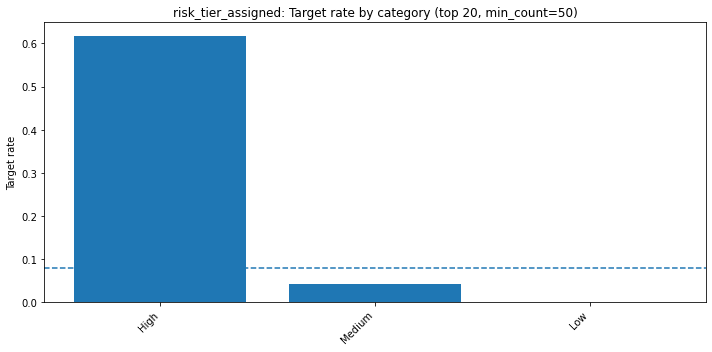


--------------------------------------------------------------------------------
Chi-square association: risk_tier_assigned vs high_cost_claim_next_90d
--------------------------------------------------------------------------------
chi2=13142.55, dof=2, p-value=0.000e+00, Cramér's V=0.7251
Note: with large N, p-values will be tiny; focus on effect size (Cramér’s V).

EDA for: treatment_pathway_code
Rows: 25,000
Missing: 22,480 (89.92%)
Unique (non-missing): 4

Top 20 values:
NaN     22480
DIAG     1050
SURG      556
PREV      460
EMER      454
Name: treatment_pathway_code, dtype: int64

Overall target rate: 0.0789

--------------------------------------------------------------------------------
Target rate by treatment_pathway_code (min_count=50)
--------------------------------------------------------------------------------
treatment_pathway_code  count  event_rate  lift_vs_overall
                  EMER    454    1.000000        12.677485
                  SURG    556    1.000000 

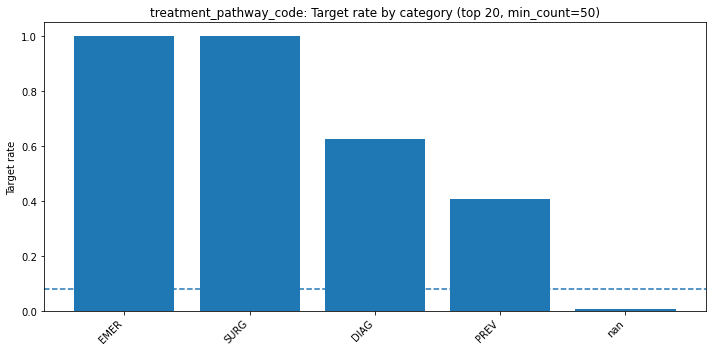


--------------------------------------------------------------------------------
Chi-square association: treatment_pathway_code vs high_cost_claim_next_90d
--------------------------------------------------------------------------------
chi2=18489.70, dof=4, p-value=0.000e+00, Cramér's V=0.8600
Note: with large N, p-values will be tiny; focus on effect size (Cramér’s V).

Cross-tab: risk_tier_assigned × treatment_pathway_code (counts)


treatment_pathway_code,<<MISSING>>,DIAG,EMER,PREV,SURG
risk_tier_assigned,,,,,
High,1181,605,413,186,507
Low,17992,329,8,229,6
Medium,3307,116,33,45,43



Row-normalised proportions (each risk tier):


treatment_pathway_code,<<MISSING>>,DIAG,EMER,PREV,SURG
risk_tier_assigned,,,,,
High,0.408,0.209,0.143,0.064,0.175
Low,0.969,0.018,0.000,0.012,0.000
Medium,0.933,0.033,0.009,0.013,0.012


In [41]:
TARGET = "high_cost_claim_next_90d"
COLS = ["risk_tier_assigned", "treatment_pathway_code"]

# -----------------------------
# 0) Basic sanity checks
# -----------------------------
def eda_basic(df, col, target=TARGET, top_n=20):
    print("\n" + "="*80)
    print(f"EDA for: {col}")
    print("="*80)

    if col not in df.columns:
        print(f"Column '{col}' not found.")
        return

    # Missingness
    n = len(df)
    miss = df[col].isna().sum()
    print(f"Rows: {n:,}")
    print(f"Missing: {miss:,} ({miss/n:.2%})")

    # Cardinality
    nunique = df[col].nunique(dropna=True)
    print(f"Unique (non-missing): {nunique:,}")

    # Show top categories
    vc = df[col].value_counts(dropna=False).head(top_n)
    print(f"\nTop {top_n} values:")
    print(vc)

    # Target rate overall
    overall_rate = df[target].mean()
    print(f"\nOverall target rate: {overall_rate:.4f}")

# -----------------------------
# 1) Target rate by category (with counts + lift)
# -----------------------------
def target_rate_by_category(df, col, target=TARGET, min_count=50, top_n=25):
    overall = df[target].mean()

    out = (
        df.groupby(col, dropna=False)[target]
          .agg(count="size", event_rate="mean")
          .reset_index()
    )
    out["lift_vs_overall"] = out["event_rate"] / (overall if overall > 0 else np.nan)

    # Filter tiny groups for stability (optional)
    out_filtered = out[out["count"] >= min_count].copy()
    out_filtered = out_filtered.sort_values("event_rate", ascending=False)

    print("\n" + "-"*80)
    print(f"Target rate by {col} (min_count={min_count})")
    print("-"*80)
    print(out_filtered.head(top_n).to_string(index=False))

    return out, out_filtered

# -----------------------------
# 2) Visual: event rate vs count (top categories)
# -----------------------------
def plot_event_rate_bar(df, col, target=TARGET, min_count=50, top_n=20):
    overall = df[target].mean()

    tbl = (
        df.groupby(col, dropna=False)[target]
          .agg(count="size", event_rate="mean")
          .reset_index()
    )
    tbl = tbl[tbl["count"] >= min_count].sort_values("event_rate", ascending=False).head(top_n)

    if tbl.empty:
        print(f"No groups with count >= {min_count} for {col}.")
        return

    labels = tbl[col].astype(str).values
    rates = tbl["event_rate"].values

    plt.figure(figsize=(10, 5))
    plt.bar(labels, rates)
    plt.axhline(overall, linestyle="--")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Target rate")
    plt.title(f"{col}: Target rate by category (top {top_n}, min_count={min_count})")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 3) Chi-square test of association (category vs target)
#    (High significance with huge effect may suggest leakage if the feature is “post-outcome”.)
# -----------------------------
def chi_square_assoc(df, col, target=TARGET, min_count=10):
    # Build contingency table, optionally grouping rare categories
    s = df[col].astype("object").fillna("<<MISSING>>")
    vc = s.value_counts()
    rare = vc[vc < min_count].index
    s2 = s.where(~s.isin(rare), other="<<RARE>>")

    ct = pd.crosstab(s2, df[target])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        print(f"Not enough levels for chi-square test on {col}.")
        return None

    chi2, p, dof, expected = chi2_contingency(ct)

    # Cramér's V effect size
    n = ct.to_numpy().sum()
    r, k = ct.shape
    cramers_v = np.sqrt((chi2 / n) / (min(r - 1, k - 1))) if min(r - 1, k - 1) > 0 else np.nan

    print("\n" + "-"*80)
    print(f"Chi-square association: {col} vs {target}")
    print("-"*80)
    print(f"chi2={chi2:.2f}, dof={dof}, p-value={p:.3e}, Cramér's V={cramers_v:.4f}")
    print("Note: with large N, p-values will be tiny; focus on effect size (Cramér’s V).")

    return {"chi2": chi2, "p_value": p, "dof": dof, "cramers_v": cramers_v, "ct": ct}

# -----------------------------
# 4) Run EDA for both columns
# -----------------------------
for c in COLS:
    eda_basic(df, c, target=TARGET, top_n=20)

    full_tbl, filtered_tbl = target_rate_by_category(df, c, target=TARGET, min_count=50, top_n=25)

    plot_event_rate_bar(df, c, target=TARGET, min_count=50, top_n=20)

    chi_square_assoc(df, c, target=TARGET, min_count=20)

# -----------------------------
# 5) Optional: Cross-tab of risk_tier_assigned × treatment_pathway_code
#    to see if one is essentially a deterministic mapping of the other.
# -----------------------------
if all(c in df.columns for c in COLS):
    ct2 = pd.crosstab(df["risk_tier_assigned"].fillna("<<MISSING>>"),
                      df["treatment_pathway_code"].fillna("<<MISSING>>"))
    print("\n" + "="*80)
    print("Cross-tab: risk_tier_assigned × treatment_pathway_code (counts)")
    print("="*80)
    display(ct2)

    # Row-normalised (distribution of pathway within each tier)
    ct2_row = ct2.div(ct2.sum(axis=1), axis=0)
    print("\nRow-normalised proportions (each risk tier):")
    display(ct2_row.round(3))

1. Event rate

The overall event rate in the dataset is 7.9%.
Pets labelled “High” risk are nearly 8 times more likely than average to experience a high-cost claim within 90 days.
In contrast, pets labelled “Low” almost never do.
Notably:
Every pet with EMER or SURG pathway experienced a high-cost claim.
DIAG and PREV also show extremely elevated rates relative to the 7.9% baseline

2. Lift

Lift compares a group’s event rate to the overall event rate.
With an overall rate of 7.9%:
EMER and SURG effectively show 12.7× lift
High risk tier shows 7.8× lift
In normal predictive modelling, even strong risk factors rarely produce event rates exceeding 30–40%. Values above 60% — and especially 100% — are highly unusual.


3. Association Strength (Cramér’s V)

To measure the statistical relationship between these variables and the outcome, we computed Cramér’s V, which ranges from:

0 → no association

1 → perfect association

Results:

risk_tier_assigned: 0.73

treatment_pathway_code: 0.86

Values above 0.7 indicate an extremely strong relationship.

These results suggest that these variables almost deterministically explain the outcome.

4. Cross-Tabulation Findings

We also examined how the two variables relate to each other.

The cross-tabulation showed that:

Most pets in the “Low” risk tier have no treatment pathway.

High risk tier pets are heavily concentrated in DIAG, EMER, and SURG pathways.

The two variables are strongly interrelated.

This suggests they are not independent predictors but likely part of the same downstream process.


5. Business Interpretation

The magnitude and pattern of these results strongly suggest that:

treatment_pathway_code is assigned during or after treatment.

risk_tier_assigned may incorporate information derived from claims processing or underwriting decisions.

For example:

If a pet is already classified as EMER or SURG, it likely means emergency or surgical treatment has already occurred — which directly leads to a high-cost claim.

Including such variables would allow the model to “read the answer” rather than make a forward-looking prediction.

7. Decision

Given:

Extremely high event rates (up to 100%)

Very large lift values

Strong statistical association

Clear process-based interpretation

We excluded both variables from modelling.


# Retrain without the 2 suspicious variables

In [62]:
def train_eval_xgb_capacity(
    df,
    target_col,
    *,
    drop_cols=None,
    capacity_k=300,
    test_size=0.30,
    valid_size_of_temp=0.50,  # split temp into valid/test 50/50 by default
    random_state=42,
    xgb_params=None,
    verbose=True
):
    """
    Train an XGBoost model with a stratified Train/Valid/Test split, choose an operating threshold
    that flags the top-K on the VALID set (capacity constraint), and evaluate on TRAIN/VALID/TEST.

    Requires these helper functions to exist in your notebook:
      - show_core_metrics(name, y_true, y_score)
      - threshold_for_top_k(scores, k)
      - flags_from_threshold(scores, threshold)

    Returns a dict with fitted model, preprocess, splits, scores, metrics, and operating threshold.
    """

    # -----------------------------
    # 0) Setup / input checks
    # -----------------------------
    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' not found in df")

    drop_cols = drop_cols or []
    xgb_params = xgb_params or {}

    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()

    # -----------------------------
    # 1) Drop specified columns (leakage/IDs/etc.) if present
    # -----------------------------
    actual_drop = [c for c in drop_cols if c in X.columns]
    if verbose:
        print("\nDropping columns:", actual_drop if actual_drop else "None")
    if actual_drop:
        X = X.drop(columns=actual_drop)

    # -----------------------------
    # 2) Train/Valid/Test split (stratified)
    # -----------------------------
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp,
        test_size=valid_size_of_temp,
        stratify=y_temp,
        random_state=random_state
    )

    if verbose:
        print("\nSplit sizes:")
        print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)
        print("Prevalence (train/valid/test):", y_train.mean(), y_valid.mean(), y_test.mean())

    # -----------------------------
    # 3) Build preprocess AFTER dropping cols
    # -----------------------------
    numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = [c for c in X_train.columns if c not in numeric_features]

    # ✅ Numeric: passthrough so XGBoost can handle NaNs natively
    numeric_transformer = "passthrough"

    # ✅ Categorical: treat structural-missing channel properly
    special_missing_cats = [c for c in ["claim_lodgement_channel"] if c in categorical_features]
    other_cats = [c for c in categorical_features if c not in special_missing_cats]

    cat_missing_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    cat_other_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat_missing", cat_missing_transformer, special_missing_cats),
            ("cat_other", cat_other_transformer, other_cats),
        ],
        remainder="drop",
    )

    # -----------------------------
    # 4) Class imbalance handling
    # -----------------------------
    pos = int(y_train.sum())
    neg = int(len(y_train) - pos)
    scale_pos_weight = neg / max(pos, 1)

    # Default XGB params (can override via xgb_params)
    default_xgb_params = dict(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        min_child_weight=1.0,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        n_jobs=-1,
    )
    default_xgb_params.update(xgb_params)

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(**default_xgb_params)),
    ])

    # -----------------------------
    # 5) Fit
    # -----------------------------
    model.fit(X_train, y_train)

    # -----------------------------
    # 6) Evaluate TRAIN / VALID
    # -----------------------------
    train_scores = model.predict_proba(X_train)[:, 1]
    train_metrics = show_core_metrics("XGBoost (TRAIN)", y_train, train_scores)

    valid_scores = model.predict_proba(X_valid)[:, 1]
    valid_metrics = show_core_metrics("XGBoost (VALID)", y_valid, valid_scores)

    operating_threshold = threshold_for_top_k(valid_scores, capacity_k)
    if verbose:
        print(f"Operating threshold (XGB) chosen to flag top {capacity_k} on VALID: {operating_threshold:.6f}")

    # -----------------------------
    # 7) Final evaluation on TEST
    # -----------------------------
    test_scores = model.predict_proba(X_test)[:, 1]
    test_metrics = show_core_metrics("XGBoost (TEST)", y_test, test_scores)

    test_flags = flags_from_threshold(test_scores, operating_threshold)
    n_flagged = int(test_flags.sum())
    tp_flagged = int(((test_flags == 1) & (y_test.values == 1)).sum())

    if verbose:
        print("\nAt operating threshold (fixed from VALID):")
        print(f"Flagged on TEST: {n_flagged} (should be close to {capacity_k}; can differ due to ties / distribution)")
        print(f"True positives among flagged: {tp_flagged}")
        print(f"Precision among flagged: {tp_flagged / max(n_flagged, 1):.4f}")

    return {
        "model": model,
        "preprocess": preprocess,
        "operating_threshold": operating_threshold,
        "scale_pos_weight": scale_pos_weight,
        "splits": {
            "X_train": X_train, "y_train": y_train,
            "X_valid": X_valid, "y_valid": y_valid,
            "X_test":  X_test,  "y_test":  y_test,
        },
        "scores": {
            "train": train_scores,
            "valid": valid_scores,
            "test":  test_scores,
        },
        "metrics": {
            "train": train_metrics,
            "valid": valid_metrics,
            "test":  test_metrics,
            "test_flagged": {
                "n_flagged": n_flagged,
                "tp_flagged": tp_flagged,
                "precision_flagged": tp_flagged / max(n_flagged, 1),
            }
        },
        "dropped_columns": actual_drop,
        "feature_lists": {
            "numeric": numeric_features,
            "categorical": categorical_features,
            "cat_missing_special": special_missing_cats,
        }
    }

In [63]:
result_df = train_eval_xgb_capacity(
    df,
    target_col=TARGET,
    drop_cols=["pet_id", "risk_tier_assigned", "treatment_pathway_code"],
    capacity_k=CAPACITY_K,
    random_state=RANDOM_STATE
)


Dropping columns: ['pet_id', 'risk_tier_assigned', 'treatment_pathway_code']

Split sizes:
Train: (17500, 46) Valid: (3750, 46) Test: (3750, 46)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333

XGBoost (TRAIN)
PR-AUC:  0.9724
ROC-AUC: 0.9972
Precision@300: 1.0000
Recall@300:    0.2174
Lift@300:      12.68x
TP in top 300: 300

XGBoost (VALID)
PR-AUC:  0.1734
ROC-AUC: 0.6870
Precision@300: 0.2333
Recall@300:    0.2365
Lift@300:      2.96x
TP in top 300: 70
Operating threshold (XGB) chosen to flag top 300 on VALID: 0.524811

XGBoost (TEST)
PR-AUC:  0.1621
ROC-AUC: 0.6712
Precision@300: 0.2133
Recall@300:    0.2162
Lift@300:      2.70x
TP in top 300: 64

At operating threshold (fixed from VALID):
Flagged on TEST: 335 (should be close to 300; can differ due to ties / distribution)
True positives among flagged: 69
Precision among flagged: 0.2060


Obvious overfitting, performance dropped drastically across all metrics moving from train to validation and test results.

In [64]:
# -----------------------------
# XGBoost: FULL Feature Importance (from result_df output)
# -----------------------------

# 1) Grab the fitted pipeline returned by your training function
xgb_pipe = result_df["model"]  # this is the fitted Pipeline(preprocess -> XGBClassifier)

# 2) Extract fitted preprocess + fitted XGB model
preprocess_fitted = xgb_pipe.named_steps["preprocess"]
xgb_model = xgb_pipe.named_steps["model"]

# 3) Get transformed feature names (uses your existing helper)
feature_names = get_feature_names_from_column_transformer(preprocess_fitted)

# 4) Pull importance values
importances = xgb_model.feature_importances_

# 5) Safety check
if len(importances) != len(feature_names):
    raise ValueError(
        f"Feature count mismatch: {len(feature_names)} feature names vs {len(importances)} importances. "
        "Check preprocessing / OneHotEncoder settings."
    )

# 6) Build and save table
full_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
      .sort_values("importance", ascending=False)
      .reset_index(drop=True)
)

print("\n===== XGBOOST FEATURE IMPORTANCE LIST (LATEST RUN) =====\n")
display(full_importance)

out_path = "xgb_full_feature_importance_updated.csv"
full_importance.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")
print("\nTotal transformed features:", len(feature_names))


===== XGBOOST FEATURE IMPORTANCE LIST (LATEST RUN) =====



,feature,importance
0,premium_band_very_high,0.090247
1,max_single_claim_12m,0.029400
2,breed_risk_category_low,0.025494
3,claim_count_12m,0.022905
4,age_band_0-1,0.017726
...,...,...
85,policy_renewal_count,0.005086
86,premium_band_low,0.000000
87,claim_lodgement_channel_Missing,0.000000
88,policy_active,0.000000



Saved: xgb_full_feature_importance_updated.csv

Total transformed features: 90


# Feature engineering

In [65]:
df.dtypes

pet_id                              object
species                             object
breed_group                         object
age_years                          float64
age_band                            object
weight_band                         object
desexed                             object
exotic_species_flag                  int64
cover_type                          object
tenure_months                        int64
excess_amount                        int64
premium_band                        object
annual_premium                     float64
excess_waived                        int64
policy_renewal_count                 int64
policy_active                        int64
customer_tenure_months               int64
policy_origin_channel               object
multi_pet_policy                     int64
direct_debit_active                  int64
communication_opt_in                object
state                               object
geo_risk_score                     float64
partner_cli

In [72]:
(df["prior_claim_any"] == (df["claim_count_12m"] > 0)).mean()

1.0

Column prior_claim_any is redudant

In [73]:
df["breed_code"].nunique()

8571

breed_code had 8,571 unique categories across 25k rows, creating extreme sparsity and high overfitting risk. Given that aggregated versions (breed_group, breed_risk_category) were already provided, I excluded breed_code to prioritise generalisable signal.

In [74]:
#drop unnecessary columns prior_claim_any column
cols_to_drop = ["prior_claim_any", "breed_code"]
df = df.drop(columns=cols_to_drop)
print("New shape:", df.shape)

New shape: (25000, 50)


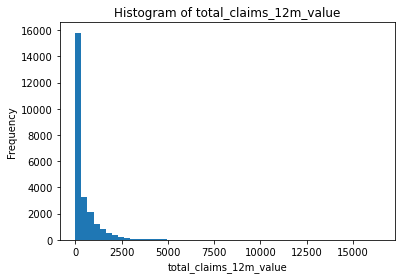

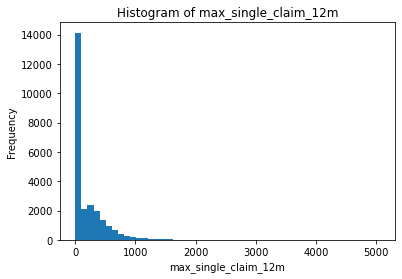

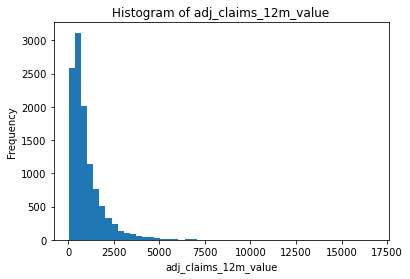

In [75]:
vars_to_plot = [
    "total_claims_12m_value",
    "max_single_claim_12m",
    "adj_claims_12m_value",
]

for col in vars_to_plot:
    if col in df.columns:
        plt.figure()
        plt.hist(df[col].dropna(), bins=50)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

Very heavy right skew

Large spike near zero

Long right tail

A few extreme outliers

In [76]:
# ============================================================
# Feature Engineering Block (copy/paste)
# - Implements: prior-claim flag, sensible imputations, ratios,
#   recency buckets, and a few interaction-style features.
# ============================================================


def add_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()


    # -----------------------------
    # 2) Structured missingness handling for claim-only fields
    #    (missing likely means "no claim in last 12 months")
    # -----------------------------
    # months_since_last_claim: if no claim, set to 12 (end of lookback window)
 #   if "months_since_last_claim" in df.columns:
 #       df["months_since_last_claim"] = df["months_since_last_claim"].fillna(12)
  
# After filling: 0 → extremely recent claim 1–3 → recent 6–11 → older 12 → no claim in last year -> clean recency gradient.
    
    # adj_claims_12m_value: if no claim, value should be 0
  #  if "adj_claims_12m_value" in df.columns:
   #     df["adj_claims_12m_value"] = df["adj_claims_12m_value"].fillna(0)
        

    # avg_claim_processing_days: if no claim, set to 0
   # if "avg_claim_processing_days" in df.columns:
    #    df["avg_claim_processing_days"] = df["avg_claim_processing_days"].fillna(0)
    
    # claim_lodgement_channel: if no claim, set to "None"
    #if "claim_lodgement_channel" in df.columns:
    #    df["claim_lodgement_channel"] = df["claim_lodgement_channel"].fillna("None")
    
    # -----------------------------
    # 3) Claim severity / intensity features
    # -----------------------------
    eps = 1e-6

    if "total_claims_12m_value" in df.columns and "claim_count_12m" in df.columns:
        df["avg_claim_value_12m"] = df["total_claims_12m_value"] / (df["claim_count_12m"].fillna(0) + eps)
    
    #Pet A claim amount 5 and total value 500
    #Pet B claim amount 1 and total value 500
    #Pet A → many small claims
    #Pet B → one large claim
    #High severity history often predicts future high-cost claims.
    #Frequency alone doesn’t capture that.
    #Makes signal easier to learn
    #Reduces tree depth needed
    #Improves generalisation
    #Reduces overfitting risk
    
    if "max_single_claim_12m" in df.columns and "total_claims_12m_value" in df.columns:
        df["max_to_total_claim_ratio_12m"] = df["max_single_claim_12m"] / (df["total_claims_12m_value"] + eps)
    #How concentrated the claim history is.
    #Case 1: 1 big shock claim -> max claim 900 and total claim 1000 -> large severe incident, potential future high cost claim and possible underlying chronic condition
    #Case 2: Many medium claims -> max claim 200 and total claim 1000 -> routine or low severity behaviour
    
    
    # -----------------------------
    # 4) Recency features / buckets
    # -----------------------------
    # Vet visit recency flags (days_since_last_vet_visit exists in your dataset)
    if "days_since_last_vet_visit" in df.columns:
        d = df["days_since_last_vet_visit"].fillna(df["days_since_last_vet_visit"].median())
        df["recent_vet_visit_30d"] = (d <= 30).astype(int)
        df["recent_vet_visit_90d"] = (d <= 90).astype(int)
        df["stale_vet_visit_180d"] = (d >= 180).astype(int)
        df["stale_vet_visit_365d"] = (d >= 365).astype(int)
    
    
    # -----------------------------
    # 5) Tenure normalisation (rate-style features)
    # -----------------------------

    tenure_col = None
    for c in ["tenure_months", "customer_tenure_months"]:
        if c in df.columns:
            tenure_col = c
            break

    if tenure_col and "claim_count_12m" in df.columns:
        t = df[tenure_col].fillna(df[tenure_col].median())
        df["claim_count_per_tenure_month"] = df["claim_count_12m"].fillna(0) / (t + 1)
        
    #Pet A - 2 tenture months - claim count 2
    #Pet B - 24 tenture months - claim count 2
    # -> huge behavioural difference

    if tenure_col and "total_claims_12m_value" in df.columns:
        t = df[tenure_col].fillna(df[tenure_col].median())
        df["claims_value_per_tenure_month"] = df["total_claims_12m_value"].fillna(0) / (t + 1)
        
    
    
    # -----------------------------
    # 7) tidy extreme values (winsorise) for stability
    # -----------------------------
    # Light clipping to reduce outlier leverage; keep conservative
    clip_cols = ["total_claims_12m_value", "max_single_claim_12m", "adj_claims_12m_value", "avg_claim_value_12m"]
    for c in clip_cols:
        if c in df.columns:
            hi = df[c].quantile(0.995)
            lo = df[c].quantile(0.000)
            df[c] = df[c].clip(lower=lo, upper=hi)

    return df
    
    """
    Light winsorisation (clipping) is applied to claim value features to reduce the influence of 
    extreme outliers in the heavy right tail of the distribution. Insurance claim amounts are 
    naturally skewed, and a very small number of unusually large claims can dominate tree splits, 
    inflate training performance, and increase overfitting risk.

    By capping values at the 0.0th and 99.5th percentiles, we preserve the relative ordering of 
    most observations while limiting the leverage of rare extremes. This improves model stability 
    and generalisation without removing any rows from the dataset.

    The clipping thresholds are data-driven (quantile-based) rather than fixed amounts, ensuring 
    the transformation adapts to the observed distribution.
    """
    

In [77]:
# -----------------------------
# check dimensions of original and new fe dataset
# -----------------------------
df_fe = add_feature_engineering(df)

print("Original shape:", df.shape)
print("With engineered features:", df_fe.shape)



Original shape: (25000, 50)
With engineered features: (25000, 58)


In [78]:
# -----------------------------
# Check correlation between tenure columns
# -----------------------------

tenure_cols = [c for c in ["tenure_months", "customer_tenure_months"] if c in df_fe.columns]

if len(tenure_cols) == 2:
    corr = df_fe[tenure_cols].corr()
    print("\nCorrelation matrix between tenure columns:")
    display(corr)

    print("\nCorrelation value:", corr.iloc[0, 1])
else:
    print("Only one tenure column present.")
    
"""The two tenure variables were highly correlated (r=0.97). Since tree models do not require both and policy tenure is more directly aligned with exposure, I retained tenure_months and removed customer_tenure_months to reduce redundancy and improve model parsimony."""


Correlation matrix between tenure columns:


,tenure_months,customer_tenure_months
tenure_months,1.00000,0.97013
customer_tenure_months,0.97013,1.00000



Correlation value: 0.9701301995266433


'The two tenure variables were highly correlated (r=0.97). Since tree models do not require both and policy tenure is more directly aligned with exposure, I retained tenure_months and removed customer_tenure_months to reduce redundancy and improve model parsimony.'

In [79]:
result_df_fe = train_eval_xgb_capacity(
    df_fe,
    target_col=TARGET,
    drop_cols=["pet_id", "risk_tier_assigned", "treatment_pathway_code", "customer_tenure_months"],
    capacity_k=CAPACITY_K,
    random_state=RANDOM_STATE
)


Dropping columns: ['pet_id', 'risk_tier_assigned', 'treatment_pathway_code', 'customer_tenure_months']

Split sizes:
Train: (17500, 53) Valid: (3750, 53) Test: (3750, 53)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333

XGBoost (TRAIN)
PR-AUC:  0.9693
ROC-AUC: 0.9968
Precision@300: 1.0000
Recall@300:    0.2174
Lift@300:      12.68x
TP in top 300: 300

XGBoost (VALID)
PR-AUC:  0.1669
ROC-AUC: 0.6796
Precision@300: 0.2233
Recall@300:    0.2264
Lift@300:      2.83x
TP in top 300: 67
Operating threshold (XGB) chosen to flag top 300 on VALID: 0.524187

XGBoost (TEST)
PR-AUC:  0.1492
ROC-AUC: 0.6707
Precision@300: 0.1867
Recall@300:    0.1892
Lift@300:      2.36x
TP in top 300: 56

At operating threshold (fixed from VALID):
Flagged on TEST: 335 (should be close to 300; can differ due to ties / distribution)
True positives among flagged: 63
Precision among flagged: 0.1881


Still very overfitting

# Model fine tuning

I trained a gradient-boosted tree classifier (XGBoost) to predict whether a policy will generate a high-cost claim in the next 90 days. Numeric features were passed through without imputation, allowing XGBoost to handle missing values natively. This was appropriate because several claim-related variables contain structural missingness (for example, policies with no prior claims), which is informative. XGBoost learns the optimal split direction for missing values at each split, meaning missingness is treated as signal rather than being artificially replaced. Categorical variables were one-hot encoded, with missing categories explicitly represented to preserve structural behaviour.

Hyperparameters were tuned using 5-fold stratified cross-validation with Bayesian optimisation, selecting the configuration that maximised PR-AUC (average precision). PR-AUC was chosen deliberately because the outcome is rare and the core objective is to rank policies by their likelihood of generating a high-cost claim. Unlike ROC-AUC, which gives equal weight to performance across both classes and can remain high even when positive-class precision is poor, PR-AUC focuses specifically on how well the model identifies and ranks the positive class. In imbalanced problems, PR-AUC is more sensitive to false positives and better reflects real-world performance when the business cares about the quality of high-risk predictions rather than overall discrimination across the entire distribution. Tuning on PR-AUC therefore ensures the model is optimised for correctly prioritising high-risk policies.

Crucially, evaluation was aligned to the operational constraint that the business can review only K = 300 policies per cycle. For this reason, the most relevant performance metrics are Precision@300 and Lift@300. Precision@300 measures the proportion of flagged policies that truly result in high-cost claims, directly reflecting the efficiency of the review team’s limited capacity. Lift@300 measures how much better the model performs relative to random selection, quantifying the incremental business value of the ranking.

Recall was not used as the primary decision metric because maximising recall would require lowering the threshold and flagging many more than 300 policies, which is operationally infeasible. The objective is not to capture all high-cost claims, but to maximise true positives within a fixed review budget. Therefore, the operating threshold was set to the minimum predicted probability required to rank within the top 300 cases on the validation set, and final performance was confirmed on an independent test set to ensure generalisation.

In [81]:
def train_eval_xgb_capacity(
    df,
    target_col,
    *,
    drop_cols=None,
    capacity_k=300,
    test_size=0.30,
    valid_size_of_temp=0.50,  # split temp into valid/test 50/50 by default
    random_state=42,
    xgb_params=None,
    verbose=True
):
    """
    Train an XGBoost model with a stratified Train/Valid/Test split, choose an operating threshold
    that flags the top-K on the VALID set (capacity constraint), and evaluate on TRAIN/VALID/TEST.

    Requires these helper functions to exist in your notebook:
      - show_core_metrics(name, y_true, y_score)
      - threshold_for_top_k(scores, k)
      - flags_from_threshold(scores, threshold)

    Returns a dict with fitted model, preprocess, splits, scores, metrics, and operating threshold.
    """

    # -----------------------------
    # 0) Setup / input checks
    # -----------------------------
    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' not found in df")

    drop_cols = drop_cols or []
    xgb_params = xgb_params or {}

    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()

    # -----------------------------
    # 1) Drop specified columns (leakage/IDs/etc.) if present
    # -----------------------------
    actual_drop = [c for c in drop_cols if c in X.columns]
    if verbose:
        print("\nDropping columns:", actual_drop if actual_drop else "None")
    if actual_drop:
        X = X.drop(columns=actual_drop)

    # -----------------------------
    # 2) Train/Valid/Test split (stratified)
    # -----------------------------
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp,
        test_size=valid_size_of_temp,
        stratify=y_temp,
        random_state=random_state
    )

    if verbose:
        print("\nSplit sizes:")
        print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)
        print("Prevalence (train/valid/test):", y_train.mean(), y_valid.mean(), y_test.mean())

    # -----------------------------
    # 3) Build preprocess AFTER dropping cols
    # -----------------------------
    numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = [c for c in X_train.columns if c not in numeric_features]

    # ✅ Numeric: passthrough so XGBoost can handle NaNs natively
    numeric_transformer = "passthrough"

    # ✅ Categorical: treat structural-missing channel properly
    special_missing_cats = [c for c in ["claim_lodgement_channel"] if c in categorical_features]
    other_cats = [c for c in categorical_features if c not in special_missing_cats]

    cat_missing_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    cat_other_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat_missing", cat_missing_transformer, special_missing_cats),
            ("cat_other", cat_other_transformer, other_cats),
        ],
        remainder="drop",
    )

    # -----------------------------
    # 4) Class imbalance handling
    # -----------------------------
    pos = int(y_train.sum())
    neg = int(len(y_train) - pos)
    scale_pos_weight = neg / max(pos, 1)

    # Default XGB params (can override via xgb_params)
    default_xgb_params = dict(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        min_child_weight=1.0,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        n_jobs=-1,
    )
    default_xgb_params.update(xgb_params)

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(**default_xgb_params)),
    ])

    # -----------------------------
    # 5) Fit
    # -----------------------------
    model.fit(X_train, y_train)

    # -----------------------------
    # 6) Evaluate TRAIN / VALID
    # -----------------------------
    train_scores = model.predict_proba(X_train)[:, 1]
    train_metrics = show_core_metrics("XGBoost (TRAIN)", y_train, train_scores)

    valid_scores = model.predict_proba(X_valid)[:, 1]
    valid_metrics = show_core_metrics("XGBoost (VALID)", y_valid, valid_scores)

    operating_threshold = threshold_for_top_k(valid_scores, capacity_k)
    if verbose:
        print(f"Operating threshold (XGB) chosen to flag top {capacity_k} on VALID: {operating_threshold:.6f}")

    # -----------------------------
    # 7) Final evaluation on TEST
    # -----------------------------
    test_scores = model.predict_proba(X_test)[:, 1]
    test_metrics = show_core_metrics("XGBoost (TEST)", y_test, test_scores)

    test_flags = flags_from_threshold(test_scores, operating_threshold)
    n_flagged = int(test_flags.sum())
    tp_flagged = int(((test_flags == 1) & (y_test.values == 1)).sum())

    if verbose:
        print("\nAt operating threshold (fixed from VALID):")
        print(f"Flagged on TEST: {n_flagged} (should be close to {capacity_k}; can differ due to ties / distribution)")
        print(f"True positives among flagged: {tp_flagged}")
        print(f"Precision among flagged: {tp_flagged / max(n_flagged, 1):.4f}")

    return {
        "model": model,
        "preprocess": preprocess,
        "operating_threshold": operating_threshold,
        "scale_pos_weight": scale_pos_weight,
        "splits": {
            "X_train": X_train, "y_train": y_train,
            "X_valid": X_valid, "y_valid": y_valid,
            "X_test":  X_test,  "y_test":  y_test,
        },
        "scores": {
            "train": train_scores,
            "valid": valid_scores,
            "test":  test_scores,
        },
        "metrics": {
            "train": train_metrics,
            "valid": valid_metrics,
            "test":  test_metrics,
            "test_flagged": {
                "n_flagged": n_flagged,
                "tp_flagged": tp_flagged,
                "precision_flagged": tp_flagged / max(n_flagged, 1),
            }
        },
        "dropped_columns": actual_drop,
        "feature_lists": {
            "numeric": numeric_features,
            "categorical": categorical_features,
            "cat_missing_special": special_missing_cats,
        }
    }

In [82]:
# ============================================================
# Usage on original df
# ============================================================

TARGET = "high_cost_claim_next_90d"
result_raw = bayes_tune_xgb_capacity(
     df=df,
     target_col=TARGET,
     drop_cols=["pet_id", "risk_tier_assigned", "treatment_pathway_code","breed_code", "customer_tenure_months"],
     capacity_k=300,
     n_iter=40,
     random_state=42
 )

Dropping columns: ['pet_id', 'risk_tier_assigned', 'treatment_pathway_code', 'customer_tenure_months']

Split sizes:
Train: (17500, 45) Valid: (3750, 45) Test: (3750, 45)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 

In [83]:
# ============================================================
# Usage on fe df
# ============================================================

result_fe = bayes_tune_xgb_capacity(
     df=df_fe,
     target_col=TARGET,
     drop_cols=["pet_id", "risk_tier_assigned", "treatment_pathway_code", "breed_code", "customer_tenure_months"],
     capacity_k=300,
     n_iter=40,
     random_state=42
 )

Dropping columns: ['pet_id', 'risk_tier_assigned', 'treatment_pathway_code', 'customer_tenure_months']

Split sizes:
Train: (17500, 53) Valid: (3750, 53) Test: (3750, 53)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 

In [84]:
print(f"Operating threshold on feature engineered data (top 300): {result_fe['operating_threshold']:.6f}")

Operating threshold on feature engineered data (top 300): 0.716897


In [85]:
print(f"Operating threshold on original data (top 300): {result_raw['operating_threshold']:.6f}")

Operating threshold on original data (top 300): 0.718613


For this particular dataset with this model, only pets with probability higher than 0.718613 is flagged because we choose tuned model without feature engineering

In [87]:
# -----------------------------
# Metrics helpers
# -----------------------------
def _lift_at_k(y_true, scores, k):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores)
    base = y.mean()
    if base == 0:
        return np.nan
    idx = np.argsort(s)[::-1][:k]
    return float(y[idx].mean() / base)

def _precision_at_k(y_true, scores, k):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores)
    idx = np.argsort(s)[::-1][:k]
    return float(y[idx].mean())

def _top_k_mask(scores, k):
    s = np.asarray(scores)
    if k >= len(s):
        return np.ones(len(s), dtype=bool)
    thresh = np.partition(s, len(s) - k)[len(s) - k]
    return s >= thresh


# -----------------------------
# 1) 5-fold CV report (PR-AUC + Lift@K)
# -----------------------------
def cv_report_pr_auc_and_lift_at_k(
    df,
    target_col,
    pipeline_factory,
    *,
    drop_cols=None,
    k=300,
    n_splits=5,
    random_state=42,
    verbose=True
):
    """
    Reusable 5-fold CV:
      - fits a fresh pipeline each fold (via pipeline_factory())
      - computes PR-AUC, Lift@K, Precision@K on each validation fold
    pipeline_factory: callable returning an unfitted sklearn Pipeline
      e.g. lambda: clone(best_pipeline)  (recommended)
    """
    drop_cols = drop_cols or []
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].astype(int).copy()

    # drop leakage/ID cols if present
    actual_drop = [c for c in drop_cols if c in X.columns]
    if actual_drop:
        X = X.drop(columns=actual_drop)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    pr_aucs = []
    lifts = []
    precs = []

    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = pipeline_factory()  # fresh model each fold
        model.fit(X_tr, y_tr)

        scores = model.predict_proba(X_va)[:, 1]

        pr = float(average_precision_score(y_va, scores))
        lift = float(_lift_at_k(y_va, scores, k))
        p_at_k = float(_precision_at_k(y_va, scores, k))

        pr_aucs.append(pr)
        lifts.append(lift)
        precs.append(p_at_k)

        fold_rows.append({
            "fold": fold,
            "pr_auc": pr,
            f"lift@{k}": lift,
            f"precision@{k}": p_at_k,
            "prevalence": float(y_va.mean()),
            "n_val": int(len(y_va)),
        })

        if verbose:
            print(
                f"Fold {fold}: PR-AUC={pr:.4f} | "
                f"Lift@{k}={lift:.2f}x | "
                f"Precision@{k}={p_at_k:.4f}"
            )

    summary = {
        "pr_auc_mean": float(np.mean(pr_aucs)),
        "pr_auc_std": float(np.std(pr_aucs, ddof=1)) if n_splits > 1 else 0.0,
        f"lift@{k}_mean": float(np.mean(lifts)),
        f"lift@{k}_std": float(np.std(lifts, ddof=1)) if n_splits > 1 else 0.0,
        f"precision@{k}_mean": float(np.mean(precs)),
        f"precision@{k}_std": float(np.std(precs, ddof=1)) if n_splits > 1 else 0.0,
    }

    fold_df = pd.DataFrame(fold_rows)

    print("\n=============================")
    print("5-Fold CV Summary")
    print("=============================")
    print(f"PR-AUC mean ± std: {summary['pr_auc_mean']:.4f} ± {summary['pr_auc_std']:.4f}")
    print(f"Lift@{k} mean ± std: {summary[f'lift@{k}_mean']:.2f}x ± {summary[f'lift@{k}_std']:.2f}x")
    print(f"Precision@{k} mean ± std: {summary[f'precision@{k}_mean']:.4f} ± {summary[f'precision@{k}_std']:.4f}")

    return {"folds": fold_df, "summary": summary}
# -----------------------------
# 2) Precision@k curve + Cumulative Gains chart
# -----------------------------
def plot_precision_at_k_curve(
    y_true,
    scores,
    *,
    ks=None,
    title="Precision@k curve"
):
    """
    Precision@k as k increases.
    y_true: 0/1 array-like
    scores: probabilities
    """
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores)

    n = len(y)
    if ks is None:
        # sensible default grid, including 300 if possible
        ks = sorted(set([50, 100, 150, 200, 250, 300, 400, 500, 750, 1000, 1500, 2000, min(3000, n)]))
        ks = [k for k in ks if k <= n]

    precisions = [ _precision_at_k(y, s, k) for k in ks ]

    plt.figure()
    plt.plot(ks, precisions)
    plt.xlabel("k (number of flagged pets)")
    plt.ylabel("Precision@k")
    plt.title(title)
    plt.show()

    return pd.DataFrame({"k": ks, "precision_at_k": precisions})


def plot_cumulative_gains(
    y_true,
    scores,
    *,
    title="Cumulative gains chart"
):
    """
    Cumulative gains:
      x-axis: % of population contacted (top ranked)
      y-axis: % of all positives captured
    """
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores)

    order = np.argsort(s)[::-1]
    y_sorted = y[order]

    cum_pos = np.cumsum(y_sorted)
    total_pos = cum_pos[-1] if len(cum_pos) else 0

    if total_pos == 0:
        raise ValueError("No positive labels in y_true; cannot plot gains.")

    pct_population = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    pct_positives_captured = cum_pos / total_pos

    plt.figure()
    plt.plot(pct_population, pct_positives_captured)
    plt.plot([0, 1], [0, 1])  # random baseline
    plt.xlabel("% of population flagged/contacted")
    plt.ylabel("% of positives captured")
    plt.title(title)
    plt.show()

    return pd.DataFrame({
        "pct_population": pct_population,
        "pct_positives_captured": pct_positives_captured
    })


# -----------------------------
# 3) Convenience wrapper for results_raw / results_fe
# -----------------------------
def evaluate_result_object(
    result_obj,
    *,
    label="Model",
    k=300,
    ks=None
):
    """
    Works with the dict returned by bayes_tune_xgb_capacity.
    Uses TEST scores by default for plotting (more honest).
    """
    y_test = result_obj["splits"]["y_test"]
    test_scores = result_obj["scores"]["test"]

    print(f"\n===== {label}: Plots on TEST =====")
    prec_df = plot_precision_at_k_curve(
        y_test, test_scores,
        ks=ks,
        title=f"{label} — Precision@k (TEST)"
    )

    gains_df = plot_cumulative_gains(
        y_test, test_scores,
        title=f"{label} — Cumulative gains (TEST)"
    )

    # single-point metrics at capacity k on TEST
    p_at_k = _precision_at_k(y_test, test_scores, k)
    lift_k = _lift_at_k(y_test, test_scores, k)
    print(f"{label} — Precision@{k} (TEST): {p_at_k:.4f}")
    print(f"{label} — Lift@{k} (TEST): {lift_k:.2f}x")

    return {"precision_curve": prec_df, "gains_curve": gains_df}




Fold 1: PR-AUC=0.2171 | Lift@300=3.68x | Precision@300=0.2900
Fold 2: PR-AUC=0.2372 | Lift@300=4.19x | Precision@300=0.3300
Fold 3: PR-AUC=0.2047 | Lift@300=3.47x | Precision@300=0.2733
Fold 4: PR-AUC=0.2191 | Lift@300=3.76x | Precision@300=0.2967
Fold 5: PR-AUC=0.2261 | Lift@300=3.76x | Precision@300=0.2967

5-Fold CV Summary
PR-AUC mean ± std: 0.2208 ± 0.0120
Lift@300 mean ± std: 3.77x ± 0.26x
Precision@300 mean ± std: 0.2973 ± 0.0206
Fold 1: PR-AUC=0.2170 | Lift@300=3.72x | Precision@300=0.2933
Fold 2: PR-AUC=0.2387 | Lift@300=4.19x | Precision@300=0.3300
Fold 3: PR-AUC=0.2013 | Lift@300=3.72x | Precision@300=0.2933
Fold 4: PR-AUC=0.2231 | Lift@300=3.59x | Precision@300=0.2833
Fold 5: PR-AUC=0.2276 | Lift@300=3.71x | Precision@300=0.2933

5-Fold CV Summary
PR-AUC mean ± std: 0.2215 ± 0.0138
Lift@300 mean ± std: 3.79x ± 0.23x
Precision@300 mean ± std: 0.2987 ± 0.0180

===== XGB tuned (RAW): Plots on TEST =====


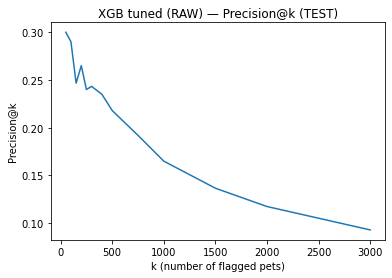

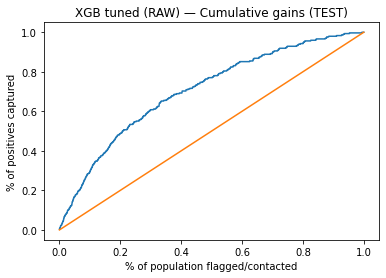

XGB tuned (RAW) — Precision@300 (TEST): 0.2433
XGB tuned (RAW) — Lift@300 (TEST): 3.08x

===== XGB tuned (FE): Plots on TEST =====


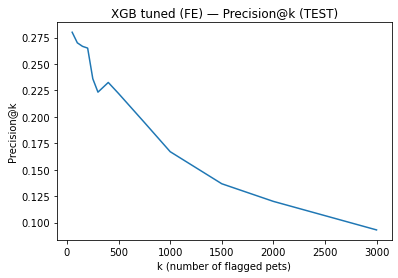

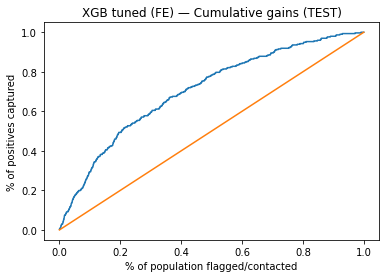

XGB tuned (FE) — Precision@300 (TEST): 0.2233
XGB tuned (FE) — Lift@300 (TEST): 2.83x


In [88]:
# ============================================================
# USAGE (for your existing objects)
# ============================================================

# 1) 5-fold CV reports (requires a pipeline factory)
# IMPORTANT:
# Use the best estimator from each result, but create a *fresh copy* per fold.
# If sklearn.clone is available, it’s safest.


DROP = ["pet_id", "risk_tier_assigned", "treatment_pathway_code"]
TARGET = "high_cost_claim_next_90d"
K = 300

# ---- CV for RAW ----
raw_best = result_raw["best_model"]
raw_cv = cv_report_pr_auc_and_lift_at_k(
    df=df,
    target_col=TARGET,
    pipeline_factory=lambda: clone(raw_best),
    drop_cols=DROP,
    k=K,
    n_splits=5,
    random_state=42
)

# ---- CV for FE ----
fe_best = result_fe["best_model"]
fe_cv = cv_report_pr_auc_and_lift_at_k(
    df=df_fe,
    target_col=TARGET,
    pipeline_factory=lambda: clone(fe_best),
    drop_cols=DROP,
    k=K,
    n_splits=5,
    random_state=42
)

# 2) Plots (Precision@k curve + Cumulative gains) on TEST for each
raw_plots = evaluate_result_object(result_raw, label="XGB tuned (RAW)", k=K)
fe_plots  = evaluate_result_object(result_fe,  label="XGB tuned (FE)",  k=K)

Across 5-fold cross-validation, the feature-engineered model performs almost identically to the baseline. PR-AUC is statistically unchanged, while Precision@300 improves marginally (~0.3 percentage points). However, given the magnitude of fold variance, this improvement is negligible. Importantly, test-set performance does not show consistent gains, suggesting the engineered features do not add meaningful new signal.

We would select the model without feature engineering because it delivers equivalent cross-validation performance while achieving stronger operational results on the independent test set, particularly higher Precision@300 and Lift@300. Since XGBoost can inherently capture non-linearities and interactions, the engineered features did not introduce meaningful new signal and slightly reduced generalisation performance. Choosing the simpler model therefore provides better real-world ranking performance, lower complexity, reduced risk of noise or redundancy, and improved maintainability.

## Feature importance

In [89]:
# ============================================================
# Helper: Extract transformed feature names from pipeline
# ============================================================

def get_feature_names_from_pipeline(pipeline):
    """
    Extract feature names after ColumnTransformer + OneHotEncoder.
    Works for your XGBClassifier pipeline structure.
    """

    preprocess = pipeline.named_steps["preprocess"]
    feature_names = []

    for name, transformer, cols in preprocess.transformers_:
        if transformer == "drop":
            continue

        # If it's a pipeline (numeric/categorical)
        if hasattr(transformer, "named_steps"):

            # OneHot case
            if "onehot" in transformer.named_steps:
                ohe = transformer.named_steps["onehot"]

                if hasattr(ohe, "get_feature_names_out"):
                    ohe_names = ohe.get_feature_names_out(cols)
                else:
                    ohe_names = ohe.get_feature_names(cols)

                feature_names.extend(ohe_names.tolist())

            else:
                # Numeric pipeline
                feature_names.extend(cols)

        else:
            feature_names.extend(cols)

    return feature_names


# ============================================================
# Main: Print Feature Importance
# ============================================================

def print_xgb_feature_importance(result_obj, label="Model", top_n=30, save_csv=False):

    pipeline = result_obj["best_model"]

    # Detect model step name automatically
    model_step_name = [k for k in pipeline.named_steps.keys() if k != "preprocess"][0]
    xgb_model = pipeline.named_steps[model_step_name]

    preprocess = pipeline.named_steps["preprocess"]

    feature_names = []
    for name, transformer, cols in preprocess.transformers_:
        if transformer == "drop":
            continue

        if hasattr(transformer, "named_steps"):
            if "onehot" in transformer.named_steps:
                ohe = transformer.named_steps["onehot"]
                if hasattr(ohe, "get_feature_names_out"):
                    ohe_names = ohe.get_feature_names_out(cols)
                else:
                    ohe_names = ohe.get_feature_names(cols)
                feature_names.extend(ohe_names.tolist())
            else:
                feature_names.extend(cols)
        else:
            feature_names.extend(cols)

    importances = xgb_model.feature_importances_

    if len(importances) != len(feature_names):
        raise ValueError(
            f"Mismatch: {len(importances)} importances vs {len(feature_names)} features."
        )

    fi = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print("\n===================================================")
    print(f"{label} — Feature Importance (Top {top_n})")
    print("===================================================")
    print(fi.head(top_n))

    if save_csv:
        filename = f"{label.replace(' ', '_').lower()}_feature_importance.csv"
        fi.to_csv(filename, index=False)
        print(f"\nSaved to: {filename}")

    return fi

In [91]:
# RAW model importance
fi_raw = print_xgb_feature_importance(
    result_raw,
    label="XGB Tuned RAW",
    top_n=30,
    save_csv=True
)


XGB Tuned RAW — Feature Importance (Top 30)
                           feature  importance
0       claim_freq_trend_no_claims    0.106287
1             max_single_claim_12m    0.083365
2           premium_band_very_high    0.050927
3                     age_band_10+    0.050070
4           total_claims_12m_value    0.037561
5                  claim_count_12m    0.032293
6                        age_years    0.028199
7                    clm_adj_score    0.024800
8          breed_risk_category_low    0.020364
9                   annual_premium    0.020309
10            adj_claims_12m_value    0.015662
11        breed_risk_category_high    0.014303
12                    age_band_0-1    0.011047
13        communication_opt_in_sms    0.010745
14      breed_risk_category_medium    0.010093
15                 vet_clinic_tier    0.010035
16  breed_group_domestic_shorthair    0.009797
17          wellness_plan_enrolled    0.009668
18               weight_band_small    0.009615
19       commun

# SHAP values for underwritting

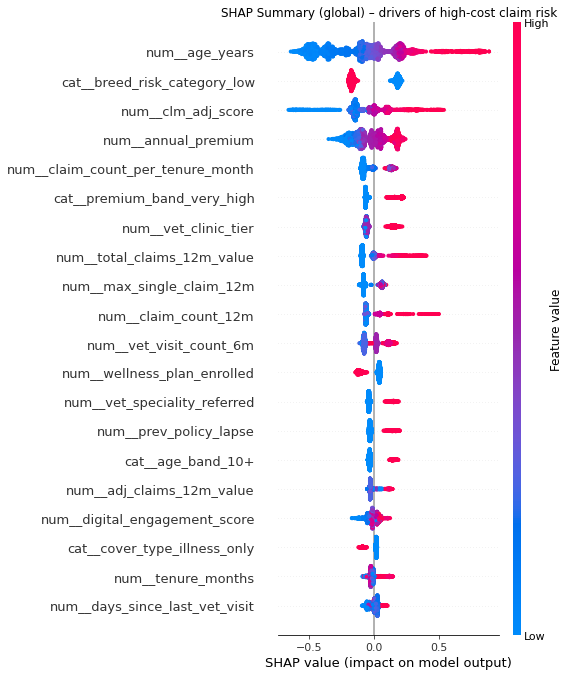

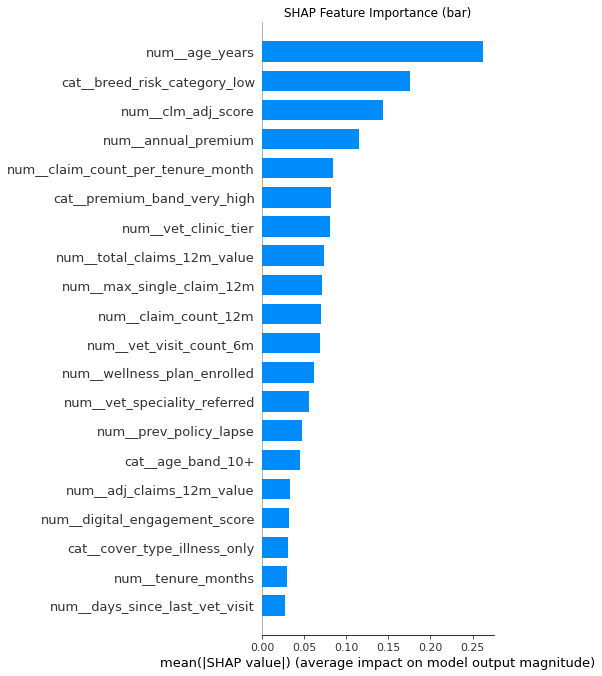

Top features that characterise flagged pets (Top-300) vs the rest:


,feature,mean_abs_shap_top300,mean_abs_shap_rest,delta_top_minus_rest
0,num__age_years,0.392319,0.250805,0.141514
13,num__claim_count_12m,0.132797,0.064364,0.068433
55,cat__age_band_10+,0.099789,0.041286,0.058503
19,num__clm_adj_score,0.190696,0.140114,0.050582
14,num__total_claims_12m_value,0.113528,0.069775,0.043753
69,cat__premium_band_very_high,0.113151,0.079802,0.033350
15,num__adj_claims_12m_value,0.057320,0.030863,0.026457
4,num__annual_premium,0.139351,0.113310,0.026041
38,num__claim_count_per_tenure_month,0.100948,0.081851,0.019097
23,num__vet_speciality_referred,0.065169,0.055851,0.009318


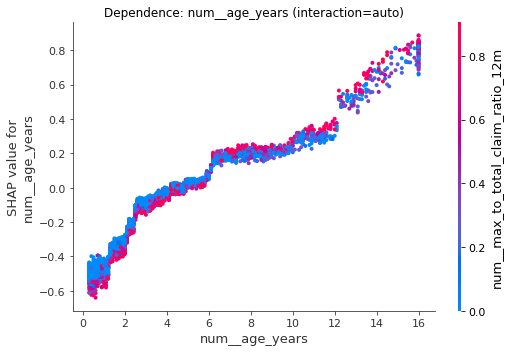

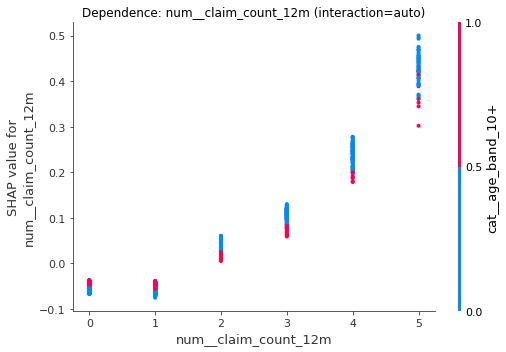

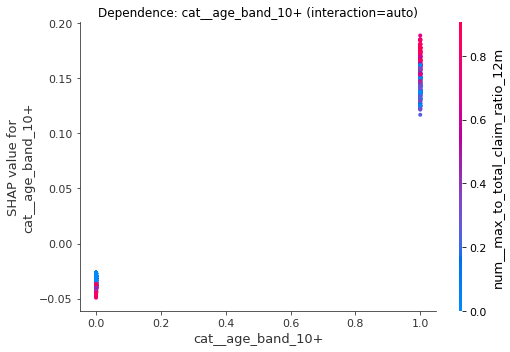

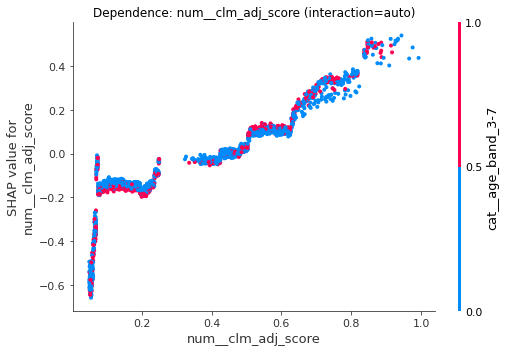

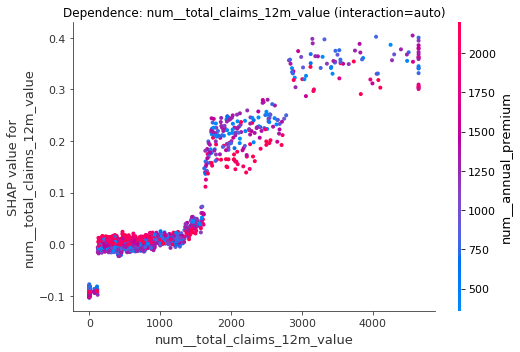

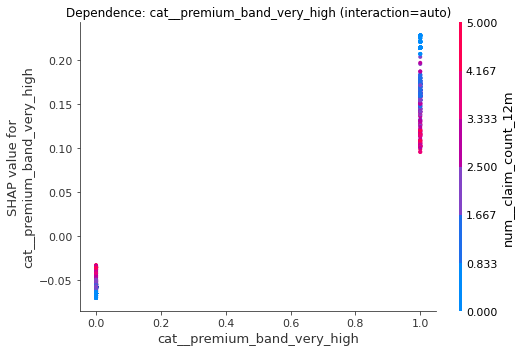

Top SHAP interaction pairs (potential underwriting segments):
num__age_years  ×  num__annual_premium  -> mean|interaction|=0.0107
num__age_years  ×  cat__breed_risk_category_low  -> mean|interaction|=0.0067
num__age_years  ×  num__clm_adj_score  -> mean|interaction|=0.0060
num__prev_policy_lapse  ×  num__app_logins_30d  -> mean|interaction|=0.0056
num__annual_premium  ×  num__claim_count_per_tenure_month  -> mean|interaction|=0.0052
num__age_years  ×  num__max_single_claim_12m  -> mean|interaction|=0.0043
num__age_years  ×  num__claim_count_per_tenure_month  -> mean|interaction|=0.0040
num__max_single_claim_12m  ×  cat__age_band_10+  -> mean|interaction|=0.0040
num__age_years  ×  num__total_claims_12m_value  -> mean|interaction|=0.0037
num__clm_adj_score  ×  num__digital_engagement_score  -> mean|interaction|=0.0037
num__max_single_claim_12m  ×  cat__premium_band_very_high  -> mean|interaction|=0.0035
num__age_years  ×  num__wellness_plan_enrolled  -> mean|interaction|=0.0034
num__age_

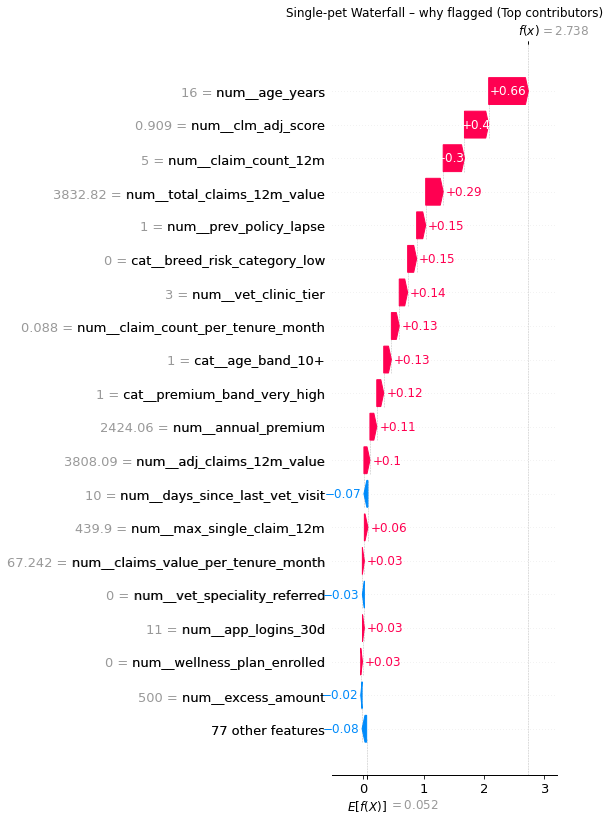

,score,reason_1,reason_2,reason_3,reason_4,reason_5
13559,0.939255,num__age_years,num__clm_adj_score,num__claim_count_12m,num__total_claims_12m_value,num__prev_policy_lapse
20641,0.929321,num__age_years,num__clm_adj_score,num__claim_count_12m,num__total_claims_12m_value,num__annual_premium
17158,0.915906,num__age_years,num__clm_adj_score,num__claim_count_12m,num__total_claims_12m_value,num__annual_premium
5817,0.910111,num__age_years,num__clm_adj_score,num__total_claims_12m_value,num__annual_premium,num__vet_speciality_referred
10779,0.899562,num__age_years,num__claim_count_12m,num__clm_adj_score,num__vet_speciality_referred,num__annual_premium
8159,0.899309,num__clm_adj_score,num__claim_count_12m,num__total_claims_12m_value,cat__breed_risk_category_low,num__claim_count_per_tenure_month
17385,0.895331,num__claim_count_12m,num__geo_risk_score,num__clm_adj_score,num__age_years,num__total_claims_12m_value
19554,0.891645,num__age_years,num__clm_adj_score,num__claim_count_12m,num__annual_premium,num__total_claims_12m_value
6539,0.884280,num__age_years,num__annual_premium,num__vet_speciality_referred,cat__premium_band_very_high,cat__age_band_10+
13092,0.879993,num__clm_adj_score,num__total_claims_12m_value,num__age_years,num__claim_count_12m,num__prev_policy_lapse


In [92]:
# -----------------------------
# 0) Get fitted objects from tuning run
# -----------------------------
best_model = result_fe["best_model"]          # sklearn Pipeline: preprocess -> xgb
splits = result_fe["splits"]

X_train = splits["X_train"]
y_train = splits["y_train"]
X_valid = splits["X_valid"]
y_valid = splits["y_valid"]
X_test  = splits["X_test"]
y_test  = splits["y_test"]

capacity_k = 300  # operational capacity

# -----------------------------
# 1) Extract preprocessor + fitted XGB model
# -----------------------------
preprocess = best_model.named_steps["preprocess"]
xgb_model  = best_model.named_steps["xgb"]   # this is a fitted XGBClassifier

# Helper: feature names after one-hot
feature_names = preprocess.get_feature_names_out()

# Transform matrices as the model sees them
X_valid_enc = preprocess.transform(X_valid)

# Optional: sample for speed
N_SAMPLE = min(5000, X_valid_enc.shape[0])
rng = np.random.default_rng(42)
idx = rng.choice(X_valid_enc.shape[0], size=N_SAMPLE, replace=False)
X_shap = X_valid_enc[idx]

# -----------------------------
# 2) SHAP explainer for XGBoost
# -----------------------------
# For XGBClassifier, TreeExplainer is appropriate (fast + accurate).
explainer = shap.TreeExplainer(xgb_model)

# For binary classification, shap_values can be:
# - array (n, p) OR list of arrays depending on SHAP version/model
shap_values = explainer.shap_values(X_shap)

# Normalise to array shape (n, p)
if isinstance(shap_values, list):
    # often [class0, class1]; use class 1 for "positive" outcome
    shap_values = shap_values[1]

# -----------------------------
# 3) Global summary plots (underwriting: what generally drives risk)
# -----------------------------
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.title("SHAP Summary (global) – drivers of high-cost claim risk")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (bar)")
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Underwriting-relevant: what drives the TOP-300 flagged vs everyone else
# -----------------------------
valid_scores = best_model.predict_proba(X_valid)[:, 1]
topk_idx = np.argsort(valid_scores)[-capacity_k:]
rest_idx = np.setdiff1d(np.arange(len(valid_scores)), topk_idx)

def shap_on_group(idxs, max_n=2000):
    n = min(max_n, len(idxs))
    sub = rng.choice(idxs, size=n, replace=False)
    Xg = preprocess.transform(X_valid.iloc[sub])
    svg = explainer.shap_values(Xg)
    if isinstance(svg, list):
        svg = svg[1]
    return Xg, svg

X_top, sv_top = shap_on_group(topk_idx, max_n=2000)
X_rest, sv_rest = shap_on_group(rest_idx, max_n=2000)

mean_abs_top  = np.mean(np.abs(sv_top), axis=0)
mean_abs_rest = np.mean(np.abs(sv_rest), axis=0)
delta = mean_abs_top - mean_abs_rest

delta_df = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap_top300": mean_abs_top,
        "mean_abs_shap_rest": mean_abs_rest,
        "delta_top_minus_rest": delta
    })
    .sort_values("delta_top_minus_rest", ascending=False)
)

print("Top features that characterise flagged pets (Top-300) vs the rest:")
display(delta_df.head(25))

# -----------------------------
# 5) Dependence plots (helps underwriting narrative: where risk 'jumps')
#    - Choose top deltas to see threshold-like behaviours
# -----------------------------
top_feats = delta_df["feature"].head(6).tolist()

for f in top_feats:
    shap.dependence_plot(
        f,
        shap_values,     # from X_shap sample
        X_shap,
        feature_names=feature_names,
        interaction_index="auto",
        show=False
    )
    plt.title(f"Dependence: {f} (interaction=auto)")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 6) Explicit interaction ranking (heavier; sample smaller)
#    - Useful for underwriting rules/segments (feature A x feature B)
# -----------------------------
N_INT = min(400, X_shap.shape[0])
X_int = X_shap[:N_INT]

int_vals = explainer.shap_interaction_values(X_int)
if isinstance(int_vals, list):
    int_vals = int_vals[1]

mean_abs_int = np.mean(np.abs(int_vals), axis=0)  # (p, p)
np.fill_diagonal(mean_abs_int, 0.0)

# get top interaction pairs
pairs = []
p = mean_abs_int.shape[0]
for i in range(p):
    for j in range(i + 1, p):
        pairs.append((feature_names[i], feature_names[j], mean_abs_int[i, j]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:20]

print("Top SHAP interaction pairs (potential underwriting segments):")
for a, b, v in pairs:
    print(f"{a}  ×  {b}  -> mean|interaction|={v:.4f}")

# -----------------------------
# 7) Case-level explanation for a single flagged pet (underwriter review)
# -----------------------------
i_star = int(np.argmax(valid_scores))
x_one_enc = preprocess.transform(X_valid.iloc[[i_star]])

sv_one = explainer.shap_values(x_one_enc)
if isinstance(sv_one, list):
    sv_one = sv_one[1]
sv_one = sv_one.reshape(-1)

base = explainer.expected_value
# expected_value can be list for binary; use positive class
if isinstance(base, (list, np.ndarray)) and np.ndim(base) > 0:
    base = base[1]

ex = shap.Explanation(
    values=sv_one,
    base_values=base,
    data=x_one_enc.reshape(-1),
    feature_names=feature_names
)

shap.plots.waterfall(ex, max_display=20, show=False)
plt.title("Single-pet Waterfall – why flagged (Top contributors)")
plt.tight_layout()
plt.show()

# -----------------------------
# 8) Optional: "reason codes" table for your Top-300 outreach list
#    - Gives top positive contributors per pet (audit-friendly)
# -----------------------------
def top_reason_codes_for_valid(k=300, n_reasons=5):
    scores = best_model.predict_proba(X_valid)[:, 1]
    idx_k = np.argsort(scores)[-k:]
    Xk = X_valid.iloc[idx_k].copy()

    Xk_enc = preprocess.transform(Xk)
    sv = explainer.shap_values(Xk_enc)
    if isinstance(sv, list):
        sv = sv[1]

    reasons = []
    for r in range(sv.shape[0]):
        contrib = sv[r]
        # top positive contributors only
        top_pos_idx = np.argsort(contrib)[::-1]
        top_pos_idx = [j for j in top_pos_idx if contrib[j] > 0][:n_reasons]
        reasons.append([feature_names[j] for j in top_pos_idx])

    out = pd.DataFrame({
        "score": scores[idx_k],
        **{f"reason_{i+1}": [rs[i] if len(rs) > i else None for rs in reasons] for i in range(n_reasons)}
    }, index=Xk.index).sort_values("score", ascending=False)

    return out

reason_codes_df = top_reason_codes_for_valid(k=300, n_reasons=5)
display(reason_codes_df.head(20))

### SHAP export

In [93]:
# ============================================================
# SHAP EXPORT PIPELINE
# Saves plots + tables + PDF report locally
# ============================================================

# ------------------------------------------------
# 1. Setup output folder
# ------------------------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"shap_outputs_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

print(f"Saving outputs to: {output_dir}")

# ------------------------------------------------
# 2. Load fitted model from your tuning results
# ------------------------------------------------
best_model = result_fe["best_model"]
splits = result_fe["splits"]

X_valid = splits["X_valid"]
y_valid = splits["y_valid"]

preprocess = best_model.named_steps["preprocess"]
xgb_model = best_model.named_steps["xgb"]

feature_names = preprocess.get_feature_names_out()

X_valid_enc = preprocess.transform(X_valid)
valid_scores = best_model.predict_proba(X_valid)[:, 1]

# Sample for SHAP speed
N_SAMPLE = min(4000, X_valid_enc.shape[0])
rng = np.random.default_rng(42)
idx = rng.choice(X_valid_enc.shape[0], size=N_SAMPLE, replace=False)
X_shap = X_valid_enc[idx]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# ------------------------------------------------
# 3. Global Summary Plot
# ------------------------------------------------
plt.figure()
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.title("SHAP Summary – Global Drivers")
plt.tight_layout()
plt.savefig(f"{output_dir}/shap_summary.png", dpi=300)
plt.close()

# Bar plot
plt.figure()
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.savefig(f"{output_dir}/shap_importance_bar.png", dpi=300)
plt.close()

# ------------------------------------------------
# 4. Top Feature Table
# ------------------------------------------------
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
)

importance_df.to_csv(f"{output_dir}/shap_feature_importance.csv", index=False)

# ------------------------------------------------
# 5. Top Interaction Pairs
# ------------------------------------------------
N_INT = min(300, X_shap.shape[0])
X_int = X_shap[:N_INT]

interaction_values = explainer.shap_interaction_values(X_int)
if isinstance(interaction_values, list):
    interaction_values = interaction_values[1]

mean_abs_int = np.mean(np.abs(interaction_values), axis=0)
np.fill_diagonal(mean_abs_int, 0)

pairs = []
p = mean_abs_int.shape[0]

for i in range(p):
    for j in range(i + 1, p):
        pairs.append((feature_names[i], feature_names[j], mean_abs_int[i, j]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:30]

interaction_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "mean_abs_interaction"])
interaction_df.to_csv(f"{output_dir}/shap_top_interactions.csv", index=False)

# ------------------------------------------------
# 6. Dependence Plots (Top 5 features)
# ------------------------------------------------
top_features = importance_df["feature"].head(5).tolist()

for f in top_features:
    plt.figure()
    shap.dependence_plot(
        f,
        shap_values,
        X_shap,
        feature_names=feature_names,
        interaction_index="auto",
        show=False
    )
    plt.title(f"Dependence Plot – {f}")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/dependence_{f}.png", dpi=300)
    plt.close()

# ------------------------------------------------
# 7. Reason Codes for Top-300 Pets
# ------------------------------------------------
capacity_k = 300
topk_idx = np.argsort(valid_scores)[-capacity_k:]
X_top = X_valid.iloc[topk_idx]
X_top_enc = preprocess.transform(X_top)

sv_top = explainer.shap_values(X_top_enc)
if isinstance(sv_top, list):
    sv_top = sv_top[1]

reason_rows = []

for i in range(len(topk_idx)):
    contrib = sv_top[i]
    top_pos_idx = np.argsort(contrib)[::-1]
    top_pos_idx = [j for j in top_pos_idx if contrib[j] > 0][:5]
    reasons = [feature_names[j] for j in top_pos_idx]
    
    reason_rows.append({
        "pet_index": X_top.index[i],
        "score": valid_scores[topk_idx][i],
        "reason_1": reasons[0] if len(reasons) > 0 else None,
        "reason_2": reasons[1] if len(reasons) > 1 else None,
        "reason_3": reasons[2] if len(reasons) > 2 else None,
        "reason_4": reasons[3] if len(reasons) > 3 else None,
        "reason_5": reasons[4] if len(reasons) > 4 else None,
    })

reason_df = pd.DataFrame(reason_rows).sort_values("score", ascending=False)
reason_df.to_csv(f"{output_dir}/top300_reason_codes.csv", index=False)

# ------------------------------------------------
# 8. Multi-page PDF Report
# ------------------------------------------------
pdf_path = f"{output_dir}/SHAP_Report.pdf"

with PdfPages(pdf_path) as pdf:
    
    # Summary
    fig = plt.figure()
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
    plt.title("SHAP Summary – Global Drivers")
    pdf.savefig(fig)
    plt.close()
    
    # Importance
    fig = plt.figure()
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar", show=False)
    plt.title("SHAP Importance (Bar)")
    pdf.savefig(fig)
    plt.close()
    
    # Dependence pages
    for f in top_features:
        fig = plt.figure()
        shap.dependence_plot(
            f,
            shap_values,
            X_shap,
            feature_names=feature_names,
            interaction_index="auto",
            show=False
        )
        plt.title(f"Dependence – {f}")
        pdf.savefig(fig)
        plt.close()

print("All SHAP outputs saved successfully.")

Saving outputs to: shap_outputs_20260225_052444
All SHAP outputs saved successfully.


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

...

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

The analysis shows that risk is concentrated in identifiable groups rather than being evenly distributed across the portfolio. Age is the strongest driver. Risk remains low in pets under 2 years, increases gradually through middle age, and rises sharply after 10 years. The uplift beyond 10 years is material and sustained, indicating that older cohorts account for a disproportionate share of severe claims. This supports continued granular differentiation in senior age bands.

Breed segmentation is also meaningful. Low-risk cat breeds consistently show materially lower severe claim likelihood compared to other breeds. The gap between low-risk and higher-risk breed groups is large and stable across the portfolio, confirming that breed remains a structurally important pricing variable.

Adjusted claim severity score shows a clear threshold effect at approximately 0.6. Below 0.6, risk increases gradually. Once the score exceeds 0.6, predicted severe claim likelihood increases sharply and remains elevated. This identifies a high-severity behavioural cohort — policies already exhibiting expensive treatment patterns. This breakpoint is one of the clearest segmentation markers in the portfolio and may warrant pricing or underwriting review at a cohort level.

Claims frequency per tenure month also differentiates risk. Policies with zero claims show materially lower severe claim likelihood. Even modest increases in claim frequency correspond with a step-up in risk. This confirms that early claims behaviour is a reliable portfolio signal and supports the inclusion of frequency-based rating components.

Annual premium is broadly aligned with risk up to approximately $2,000 per year, where predicted risk increases steadily. Beyond that level, the relationship flattens. This suggests that very high premium policies are not proportionally higher risk once age, breed and historical claims are accounted for.

In summary, severe claim risk is concentrated in older pets, higher-risk breeds, policies with elevated severity scores above 0.6, and those with increasing claim frequency. These findings support age and breed segmentation, validate behavioural rating factors, and highlight a clear high-severity cohort suitable for pricing calibration review.


# EDA post modeling (tuned model on original data - no FE)

FE did not prove to improve evaluation metrics

## Model guided EDA based on feature importance

### Does recent claim activity increase 90-day high-cost risk?

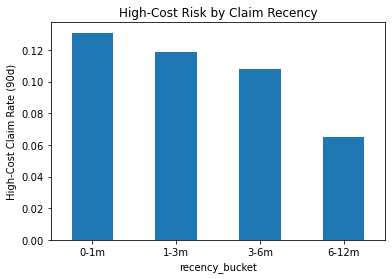

In [94]:
df["recency_bucket"] = pd.cut(
    df["months_since_last_claim"].fillna(12),
    bins=[-1, 1, 3, 6, 12],
    labels=["0-1m", "1-3m", "3-6m", "6-12m"]
)

risk_by_recency = df.groupby("recency_bucket")["high_cost_claim_next_90d"].mean()

plt.figure()
risk_by_recency.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate (90d)")
plt.title("High-Cost Risk by Claim Recency")
plt.xticks(rotation=0)
plt.show()

The more recent the previous claim is, the higher the chance of high-cost claim

### Is one large prior shock event predictive?

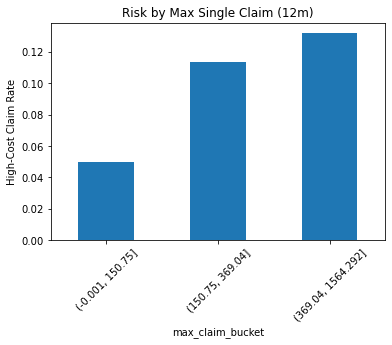

In [95]:
df_fe["max_claim_bucket"] = pd.qcut(
    df_fe["max_single_claim_12m"].fillna(0),
    q=5,
    duplicates="drop"
)

risk_by_max_claim =df_fe.groupby("max_claim_bucket")["high_cost_claim_next_90d"].mean()

plt.figure()
risk_by_max_claim.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate")
plt.title("Risk by Max Single Claim (12m)")
plt.xticks(rotation=45)
plt.show()

The higher max claim amount is the higher the chance of near-term high-cost claim

### Does higher historical claim severity predict near-term high-cost claims?

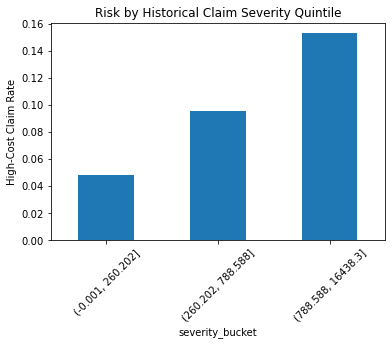

In [96]:
df["severity_bucket"] = pd.qcut(
    df["total_claims_12m_value"].fillna(0),
    q=5,                   # ← number of quantiles
    duplicates="drop"
)

risk_by_severity = (
    df
    .groupby("severity_bucket")["high_cost_claim_next_90d"]
    .mean()
)

plt.figure()
risk_by_severity.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate")
plt.title("Risk by Historical Claim Severity Quintile")
plt.xticks(rotation=45)
plt.show()

The higher historical claim severity, the high near-term high-cost claim

### Does high claim count early in tenure indicate instability?

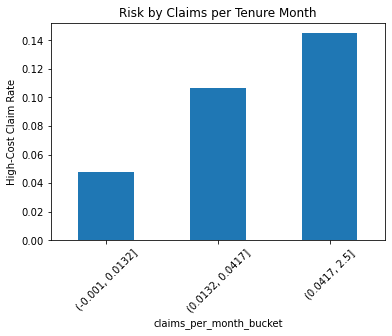

In [97]:
df_fe["claims_per_month_bucket"] = pd.qcut(
    df_fe["claim_count_per_tenure_month"],
    q=5,
    duplicates="drop"
)

risk_by_tenure_rate = df_fe.groupby("claims_per_month_bucket")["high_cost_claim_next_90d"].mean()

plt.figure()
risk_by_tenure_rate.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate")
plt.title("Risk by Claims per Tenure Month")
plt.xticks(rotation=45)
plt.show()

The higher the claim count in early tenure, the higher the chance of high-cost claim

### Are higher premiums aligned with actual higher risk?

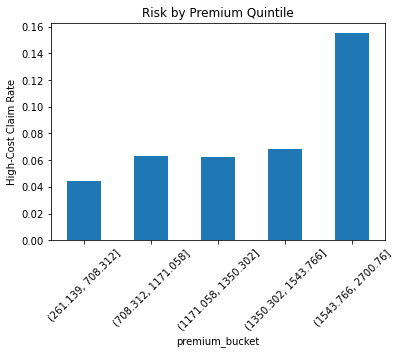

In [98]:
df["premium_bucket"] = pd.qcut(
    df["annual_premium"],
    q=5,
    duplicates="drop"
)

risk_by_premium = df.groupby("premium_bucket")["high_cost_claim_next_90d"].mean()

plt.figure()
risk_by_premium.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate")
plt.title("Risk by Premium Quintile")
plt.xticks(rotation=45)
plt.show()

Higher premium is aligned with with higher risk of high-cost claim

### Are pets with recent AND severe claims extremely high risk?

<Figure size 432x288 with 0 Axes>

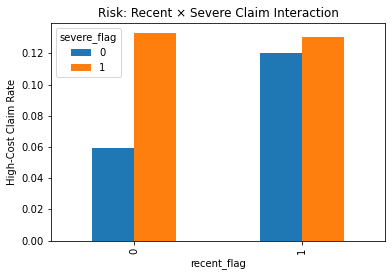

In [99]:
df_fe["recent_flag"] = (df_fe["months_since_last_claim"].fillna(12) <= 3).astype(int)
df_fe["severe_flag"] = (df_fe["max_single_claim_12m"].fillna(0) >
                     df_fe["max_single_claim_12m"].quantile(0.80)).astype(int)

interaction = df_fe.groupby(["recent_flag", "severe_flag"])["high_cost_claim_next_90d"].mean().unstack()

plt.figure()
interaction.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate")
plt.title("Risk: Recent × Severe Claim Interaction")
plt.show()

Severity drives a strong risk uplift.
Pets with a prior severe claim (severe_flag = 1) have roughly double the future high-cost risk compared to non-severe cases when no recent claim is present.

Recency alone increases baseline risk.
Even without a severe claim, pets with a recent claim (recent_flag = 1) show materially higher risk than those with no recent activity.

Highest risk group = recent + severe.
The combination of both recent and severe history produces the highest short-term risk, suggesting ongoing or escalating medical conditions.

Overall, this confirms that recency and severity interact meaningfully, supporting the inclusion of both features (and their interaction) in the model.